# 🩺 Health Status Classification — Enterprise ML Pipeline
### AI-Powered Health & Lifestyle Analytics Framework

> **Dataset:** 6,000 individuals · 15 features · 4-class health target  
> **Stack:** Scikit-learn · XGBoost · LightGBM · CatBoost · Optuna · SHAP  
> **Authors:** Enterprise ML Pipeline · Production-Grade · Portfolio-Ready

---

| Phase | Section |
|-------|---------|
| 0 | Environment & Configuration |
| 1 | Problem Understanding |
| 2 | Advanced Data Quality Analysis |
| 3 | Exploratory Data Analysis |
| 4 | Feature Engineering |
| 5 | Feature Selection |
| 6 | Preprocessing Pipeline |
| 7 | Baseline Models |
| 8 | Hyperparameter Optimization |
| 9 | Ensemble Learning |
| 10 | Comprehensive Evaluation |
| 11 | Explainable AI (SHAP) |
| 12 | Artifact Export & Report |


In [1]:
pip install -q catboost optuna shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.6 MB/s eta 0:00:00


## Phase 0 — Environment & Pipeline Initialization

In [2]:
# ── Core libraries ────────────────────────────────────────────────────────
import os, sys, time, warnings, logging, platform, json, zipfile, shutil
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV, GridSearchCV)
from sklearn.preprocessing import (LabelEncoder, StandardScaler, RobustScaler,
    PowerTransformer, OrdinalEncoder)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import (SelectKBest, chi2, f_classif,
    mutual_info_classif, RFECV, SelectFromModel)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier,
    VotingClassifier, StackingClassifier)
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report)
import joblib

# ── Advanced boosting ──────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from catboost import CatBoostClassifier, Pool

# ── Optimization ──────────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Explainability ─────────────────────────────────────────────────────────
import shap

print("✅ All libraries imported successfully")


✅ All libraries imported successfully


In [3]:
# ── Reproducibility & Seed Management ─────────────────────────────────────
SEED = 42
np.random.seed(SEED)
import random; random.seed(SEED)

try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass

# ── Global Configuration ───────────────────────────────────────────────────
CONFIG = {
    "project_name":  "Health_Status_Classification",
    "version":       "2.0.0",
    "seed":          SEED,
    "test_size":     0.20,
    "cv_folds":      5,
    "data_path":     "/content/Health_Status_Dataset.csv",
    "local_path":    "healthy_diet_calorie_intake.csv",
    "target":        "Health_Status",
    "drop_cols":     ["Person_ID"],
    "class_order":   ["Underweight", "Healthy", "Overweight", "Obese"],
    "palette":       "Set2",
    "output_dir":    "Health_Status_AI_Project/outputs",
    "n_trials_optuna": 30,
    "top_k_features":  12,
}

# ── Logging ────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("HealthML")

# ── Output directories ─────────────────────────────────────────────────────
DIRS = ["eda","preprocessing","features","models","tuning","evaluation","xai","reports"]
for d in DIRS:
    os.makedirs(f"{CONFIG['output_dir']}/{d}", exist_ok=True)

# ── System diagnostics ─────────────────────────────────────────────────────
print(f"{'='*60}")
print(f"  PROJECT : {CONFIG['project_name']} v{CONFIG['version']}")
print(f"  DATE    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  PYTHON  : {sys.version.split()[0]}")
print(f"  OS      : {platform.system()} {platform.release()}")
print(f"  SEED    : {SEED}")
print(f"{'='*60}")
print(f"  numpy   {np.__version__}  |  pandas  {pd.__version__}")
print(f"  sklearn {__import__('sklearn').__version__}  |  xgboost {xgb.__version__}")
print(f"  lightgbm {lgb.__version__}  |  catboost {cb.__version__}")
print(f"  optuna  {optuna.__version__}  |  shap  {shap.__version__}")
print(f"{'='*60}")

# ── Experiment Tracker ─────────────────────────────────────────────────────
EXPERIMENT = {"models": {}, "best_model": None, "start_time": time.time()}

logger.info("Pipeline initialized — all systems ready.")


  PROJECT : Health_Status_Classification v2.0.0
  DATE    : 2026-07-02 04:07:15
  PYTHON  : 3.12.13
  OS      : Linux 6.6.122+
  SEED    : 42
  numpy   2.0.2  |  pandas  2.2.2
  sklearn 1.6.1  |  xgboost 3.3.0
  lightgbm 4.6.0  |  catboost 1.2.10
  optuna  4.9.0  |  shap  0.52.0


## Phase 1 — Problem Understanding

### Healthcare Analytics Objective
Health status classification enables **early identification of lifestyle-driven risk factors** — obesity,
undernutrition, and sedentary behavior — that are leading preventable causes of chronic disease.  
Predicting health status from routine biometric and dietary data allows:

- **Proactive intervention**: flag at-risk individuals before clinical signs appear.
- **Personalised nutrition guidance**: tailor caloric and macronutrient targets.
- **Population health analytics**: identify systemic patterns across demographics.

### ML Objective
| | |
|--|--|
| **Input** | Biometric features (Age, Height, Weight, BMI) + Lifestyle features (Activity, Diet, Macros, Hydration) |
| **Output** | Health classification: `Underweight` · `Healthy` · `Overweight` · `Obese` |
| **Task** | Multi-class supervised classification |
| **Evaluation** | Accuracy · F1-Macro · ROC-AUC · MCC · Cohen-κ |


## Phase 2 — Advanced Data Quality Analysis

In [4]:
# ── Data Loading ──────────────────────────────────────────────────────────
for path in [CONFIG["data_path"], CONFIG["local_path"],
             "/mnt/user-data/uploads/healthy_diet_calorie_intake.csv"]:
    try:
        df_raw = pd.read_csv(path)
        logger.info(f"Data loaded from: {path}")
        break
    except FileNotFoundError:
        continue

print(f"\n📦 Shape      : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"💾 Memory     : {df_raw.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"🔢 Numerics   : {df_raw.select_dtypes(include='number').shape[1]} cols")
print(f"🔤 Categorics : {df_raw.select_dtypes(include='object').shape[1]} cols")
df_raw.head()



📦 Shape      : 6,000 rows × 15 columns
💾 Memory     : 2137.1 KB
🔢 Numerics   : 10 cols
🔤 Categorics : 5 cols


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


,dtype,non_null,missing,miss_%,unique,example
Person_ID,object,6000,0,0.0,6000,P0001
Age,int64,6000,0,0.0,63,50
Gender,object,6000,0,0.0,3,Male
Height_cm,float64,6000,0,0.0,460,176.4
Weight_kg,float64,6000,0,0.0,633,74.8
BMI,float64,6000,0,0.0,255,24.0
Activity_Level,object,6000,0,0.0,5,Very Active
Daily_Calorie_Requirement,int64,6000,0,0.0,1855,2852
Daily_Calorie_Consumed,int64,6000,0,0.0,2218,2625
Protein_Intake_g,float64,6000,0,0.0,2098,183.0


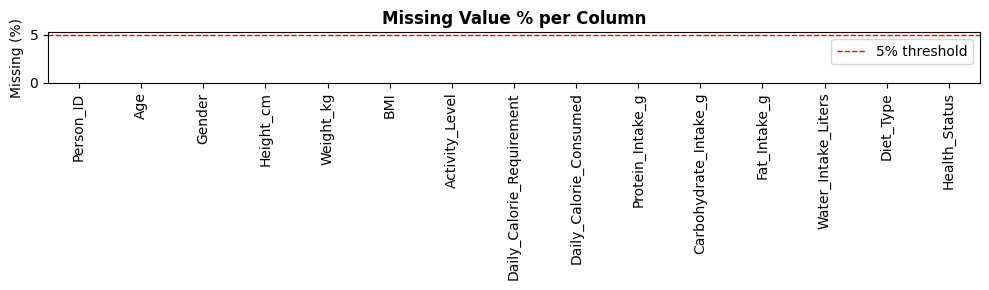

✅ No missing values


In [5]:
# ── Detailed Column Profile ────────────────────────────────────────────────
profile = pd.DataFrame({
    "dtype":    df_raw.dtypes,
    "non_null": df_raw.notnull().sum(),
    "missing":  df_raw.isnull().sum(),
    "miss_%":   (df_raw.isnull().mean()*100).round(2),
    "unique":   df_raw.nunique(),
    "example":  [df_raw[c].dropna().iloc[0] if df_raw[c].notnull().any() else None
                 for c in df_raw.columns],
})
display(profile)

# Missing value visualisation
fig, ax = plt.subplots(figsize=(10, 3))
miss = df_raw.isnull().mean() * 100
miss.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Missing Value % per Column", fontweight='bold')
ax.set_ylabel("Missing (%)")
ax.axhline(5, color='red', linestyle='--', lw=1, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/missing_values.png", dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ No missing values" if df_raw.isnull().sum().sum()==0 else f"⚠️ Missing values detected")


In [6]:
# ── Duplicate Detection ────────────────────────────────────────────────────
n_dup = df_raw.duplicated().sum()
n_id_dup = df_raw['Person_ID'].duplicated().sum() if 'Person_ID' in df_raw else 0
print(f"Duplicate rows     : {n_dup}")
print(f"Duplicate Person_IDs: {n_id_dup}")
print(f"Dataset quality    : {'✅ Clean' if n_dup == 0 else '⚠️ Duplicates found'}")


Duplicate rows     : 0
Duplicate Person_IDs: 0
Dataset quality    : ✅ Clean


In [7]:
# ── Feature Quality Assessment ─────────────────────────────────────────────
num_cols = df_raw.select_dtypes(include='number').columns.drop('Person_ID', errors='ignore').tolist()
cat_cols = [c for c in df_raw.select_dtypes(include='object').columns
            if c not in ['Person_ID', CONFIG['target']]]

print(f"Numerical features  ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")
print()

# Stats
q = df_raw[num_cols].describe().T
q['skew'] = df_raw[num_cols].skew().round(3)
q['kurt'] = df_raw[num_cols].kurt().round(3)
display(q.round(2))


Numerical features  (10): ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
Categorical features (3): ['Gender', 'Activity_Level', 'Diet_Type']



,count,mean,std,min,25%,50%,75%,max,skew,kurt
Age,6000.0,48.82,18.14,18.0,33.0,48.00,65.00,80.0,0.04,-1.20
Height_cm,6000.0,168.59,9.16,145.0,161.7,168.20,175.20,198.6,0.13,-0.47
Weight_kg,6000.0,74.07,12.42,40.0,65.5,74.10,82.70,116.6,-0.00,-0.26
BMI,6000.0,26.09,4.16,12.9,23.3,26.00,28.90,44.0,0.16,0.08
Daily_Calorie_Requirement,6000.0,2286.22,469.54,1223.0,1941.0,2232.50,2581.25,4079.0,0.52,-0.04
Daily_Calorie_Consumed,6000.0,2490.52,602.28,1000.0,2057.0,2433.00,2859.00,5158.0,0.51,0.28
Protein_Intake_g,6000.0,123.77,62.00,17.4,78.8,108.90,155.10,457.5,1.11,1.13
Carbohydrate_Intake_g,6000.0,288.04,123.91,-23.6,229.1,297.15,366.12,729.7,-0.35,0.19
Fat_Intake_g,6000.0,93.70,43.95,23.2,65.9,82.30,105.10,341.7,1.89,4.22
Water_Intake_Liters,6000.0,2.73,0.68,1.5,2.2,2.60,3.10,5.0,0.76,0.12


## Phase 3 — Advanced Exploratory Data Analysis

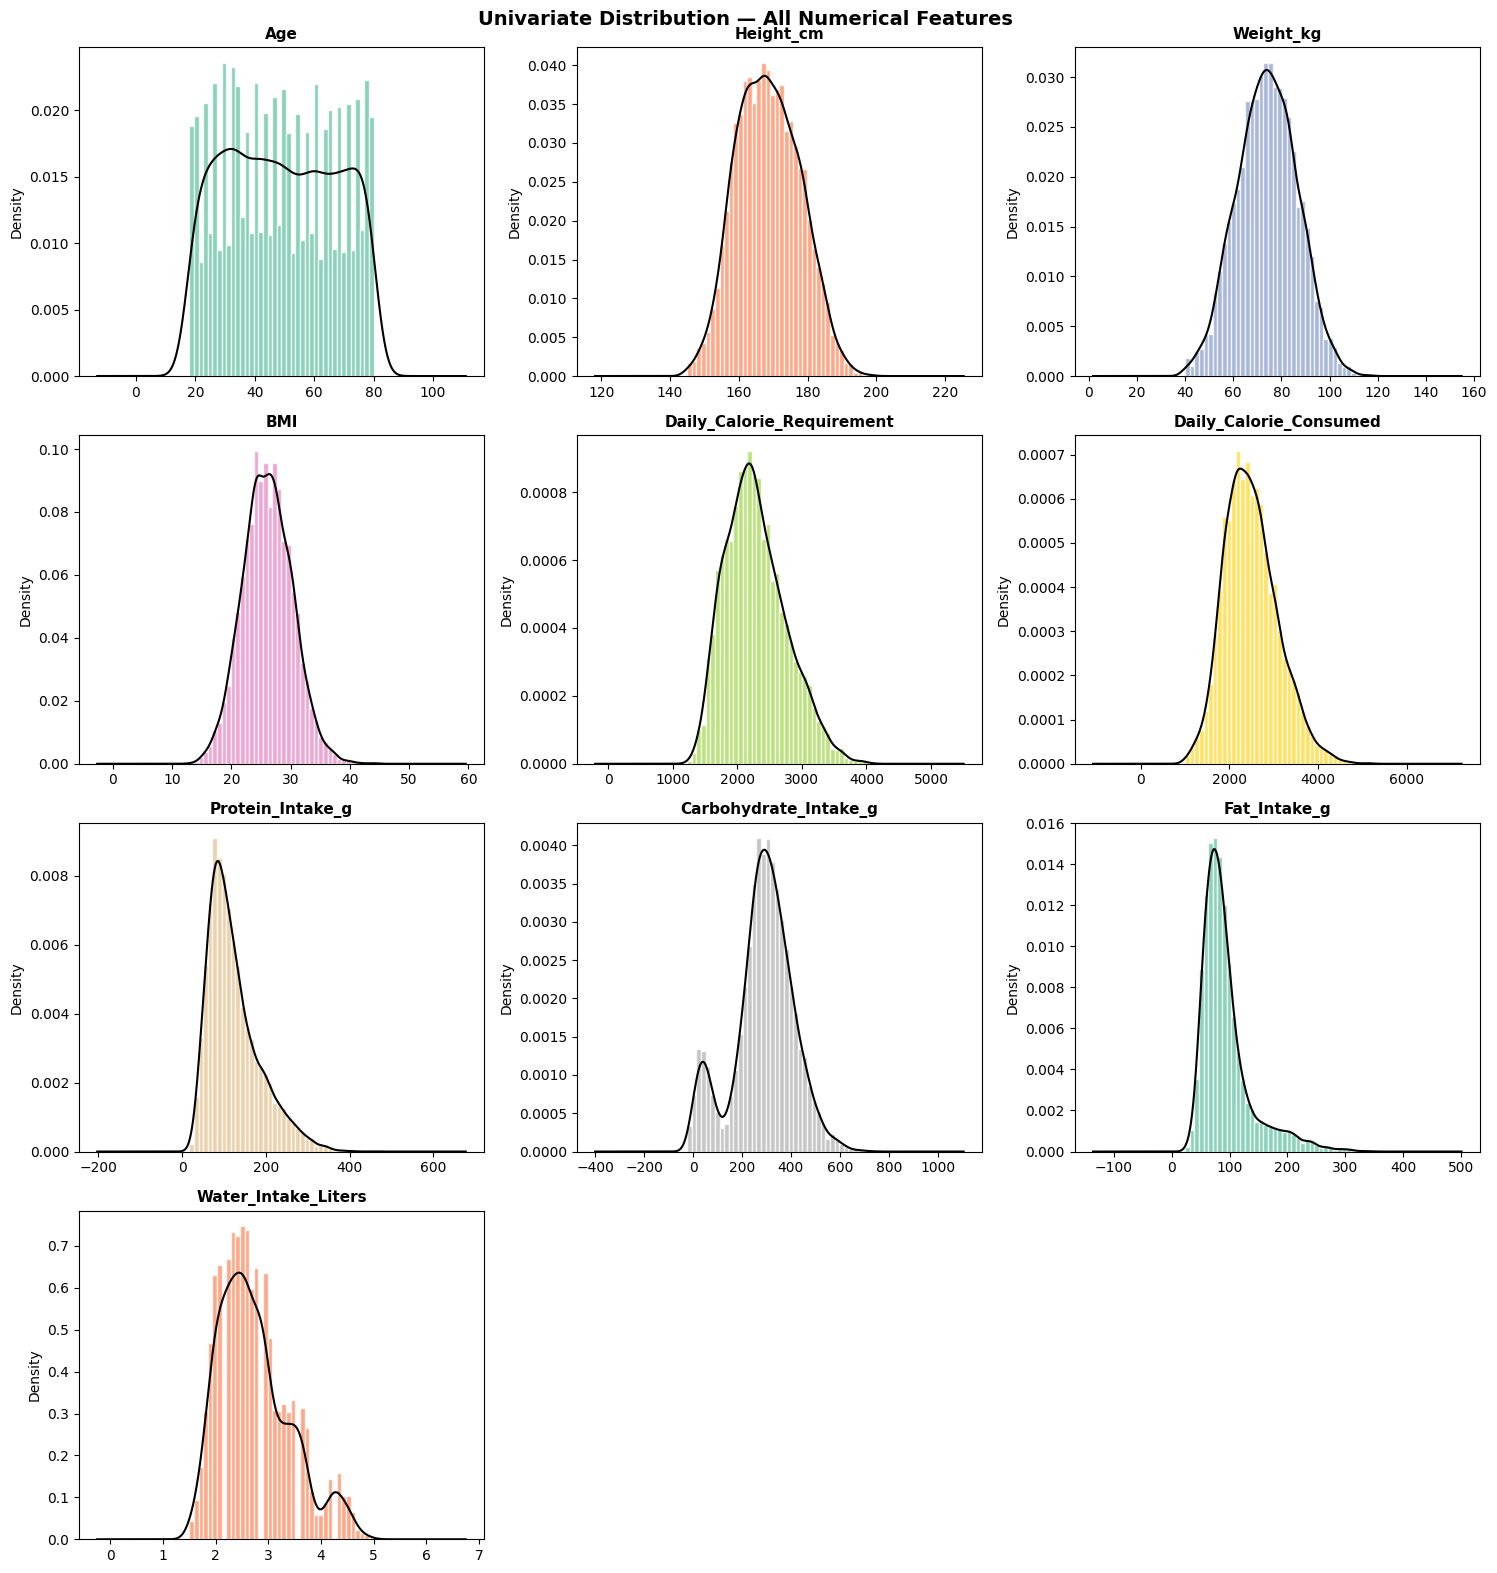

In [8]:
# ── Univariate: Histogram + KDE + Boxplot + Violin ───────────────────────
import math

n_cols_layout = 3
n_rows_layout = math.ceil(len(num_cols) / n_cols_layout)

fig, axes = plt.subplots(n_rows_layout, n_cols_layout,
                         figsize=(15, 4 * n_rows_layout))
axes = axes.flatten()
pal = sns.color_palette(CONFIG['palette'], len(num_cols))

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df_raw[col].dropna(), bins=40, color=pal[i],
            edgecolor='white', alpha=0.75, density=True)
    df_raw[col].plot(kind='kde', ax=ax, color='black', linewidth=1.5)
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distribution — All Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/univariate_distributions.png", dpi=120, bbox_inches='tight')
plt.show()


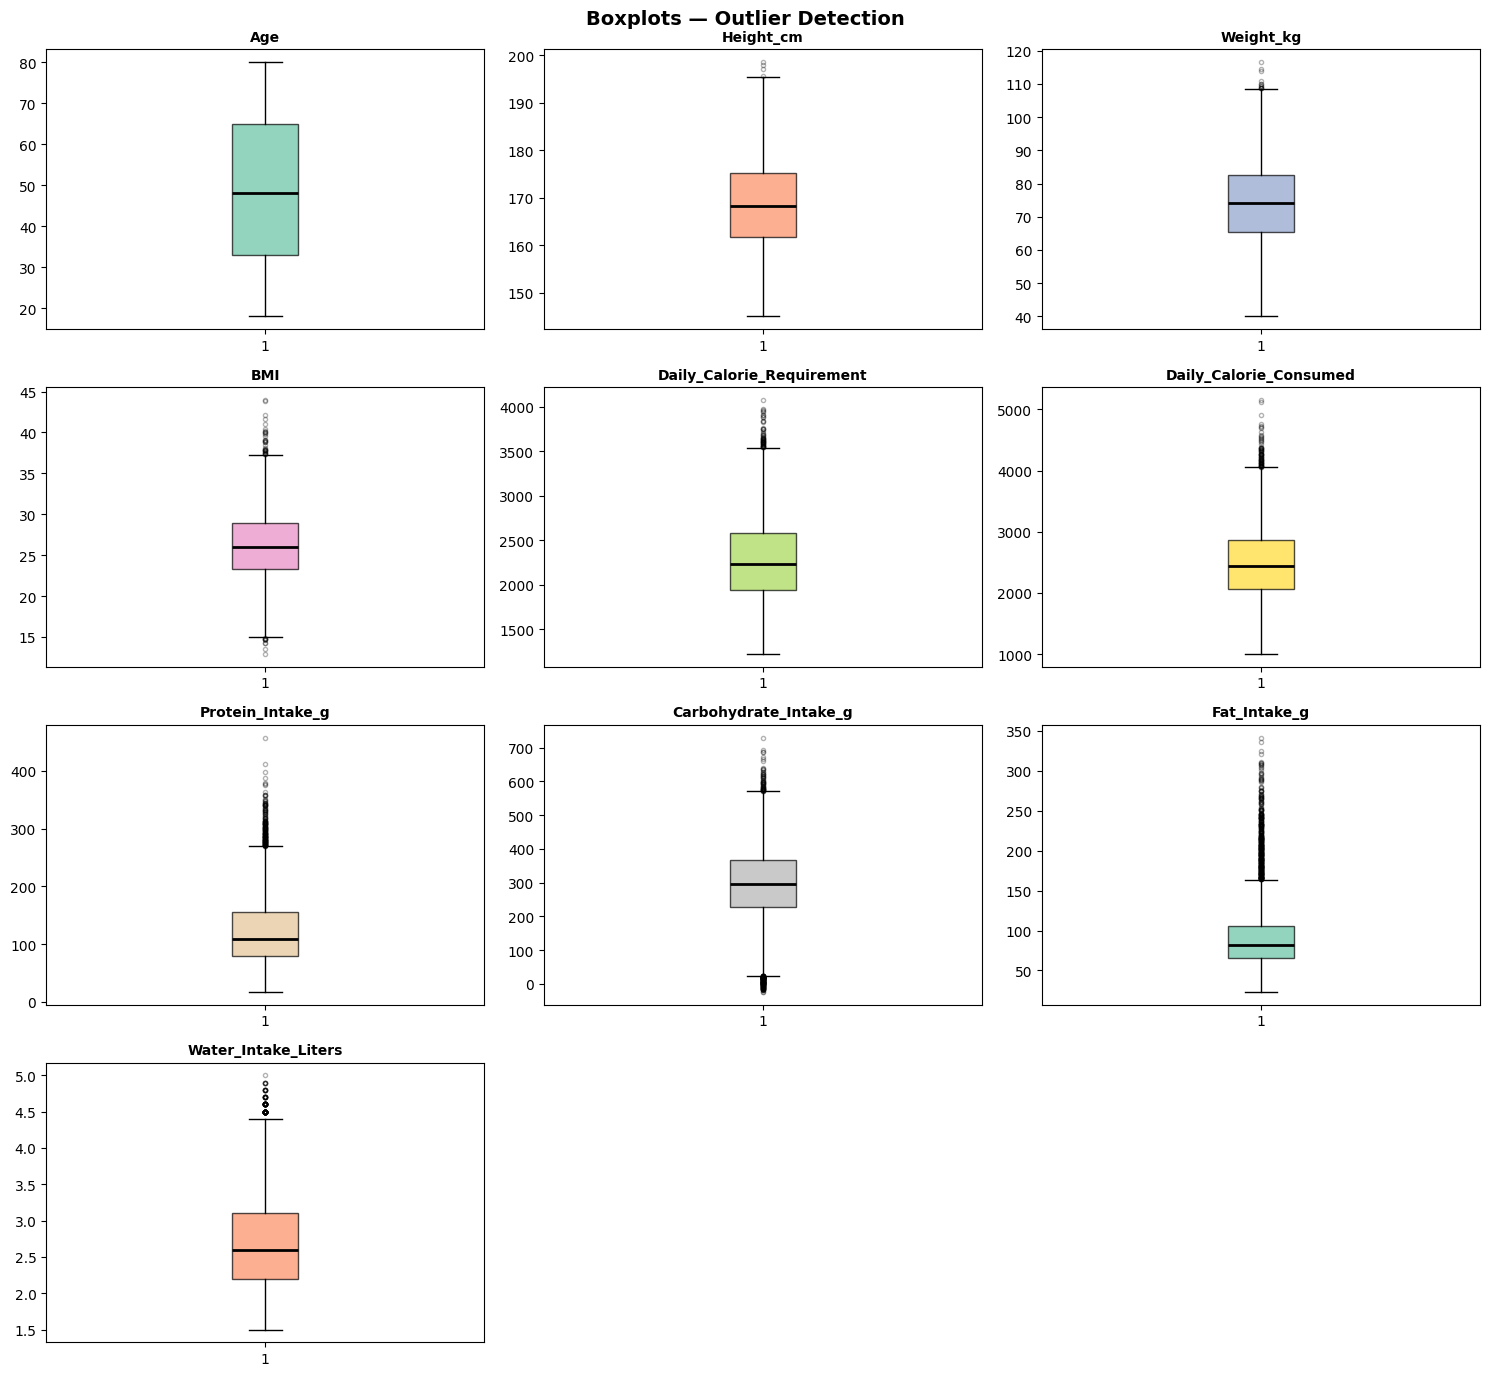

IQR Outlier Counts:
  Age                                 0 (0.0%)
  Height_cm                           4 (0.1%)
  Weight_kg                          12 (0.2%)
  BMI                                43 (0.7%)
  Daily_Calorie_Requirement          56 (0.9%)
  Daily_Calorie_Consumed             74 (1.2%)
  Protein_Intake_g                  188 (3.1%)
  Carbohydrate_Intake_g             246 (4.1%)
  Fat_Intake_g                      499 (8.3%)  ⚠️
  Water_Intake_Liters               114 (1.9%)


In [9]:
# ── Boxplots + Outlier Summary ────────────────────────────────────────────
fig, axes = plt.subplots(n_rows_layout, n_cols_layout,
                         figsize=(15, 3.5 * n_rows_layout))
axes = axes.flatten()

outlier_report = {}
for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.boxplot(df_raw[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=pal[i], alpha=0.7),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', markersize=3, alpha=0.3))
    ax.set_title(col, fontweight='bold', fontsize=10)
    Q1, Q3 = df_raw[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    out = ((df_raw[col] < Q1-1.5*IQR) | (df_raw[col] > Q3+1.5*IQR)).sum()
    outlier_report[col] = out

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/boxplots_outliers.png", dpi=120, bbox_inches='tight')
plt.show()

print("IQR Outlier Counts:")
for col, n in outlier_report.items():
    flag = "  ⚠️" if n / len(df_raw) > 0.05 else ""
    print(f"  {col:<32} {n:>4} ({n/len(df_raw)*100:.1f}%){flag}")


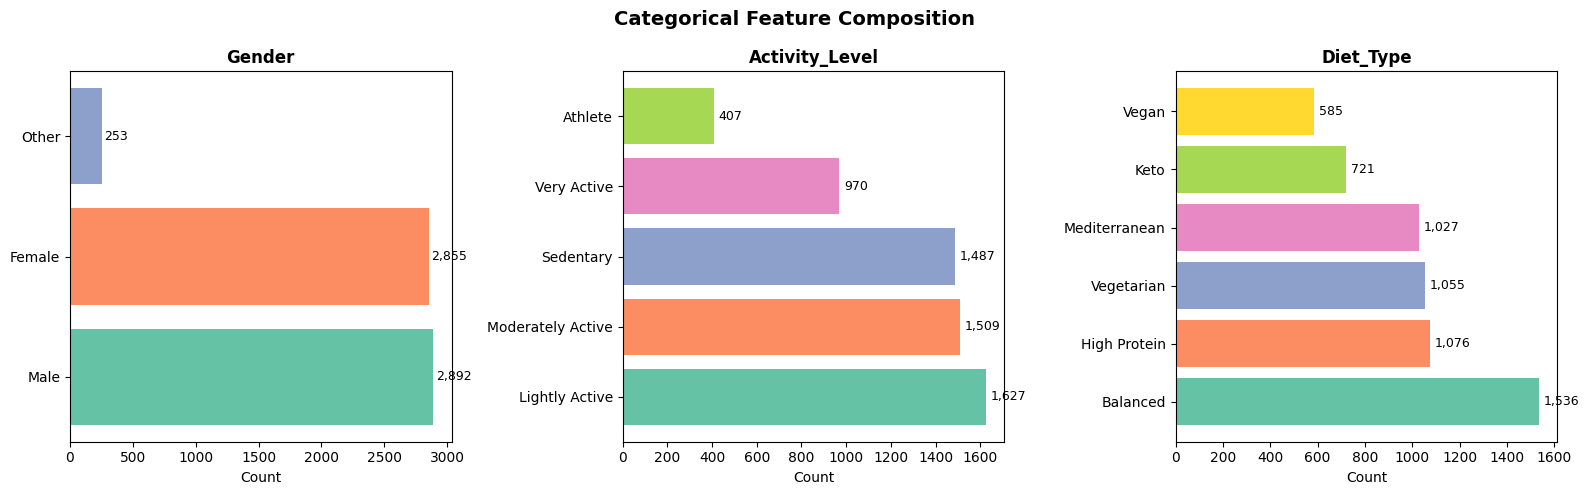

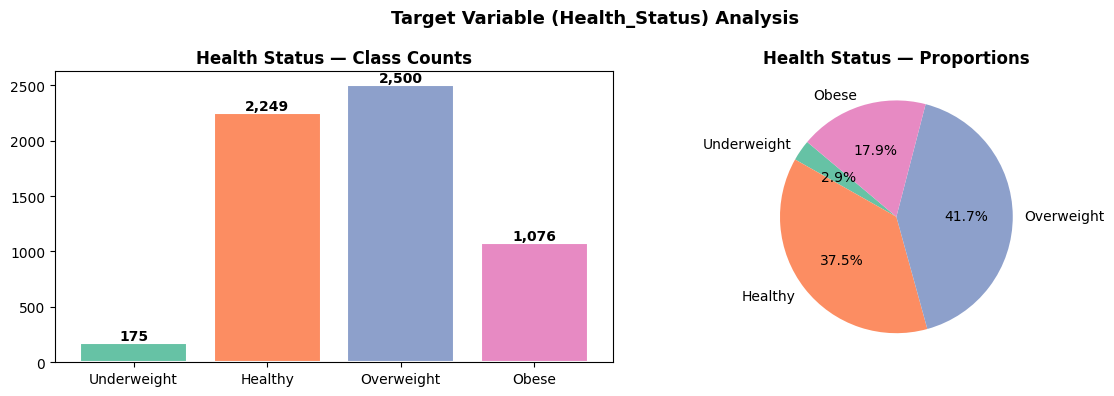

Class imbalance ratio (max/min): 14.3x
→ Moderate imbalance — stratified split + weighted metrics recommended


In [10]:
# ── Categorical Composition & Target Analysis ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_cols):
    counts = df_raw[col].value_counts()
    axes[i].barh(counts.index, counts.values,
                 color=sns.color_palette(CONFIG['palette'], len(counts)))
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('Count')
    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
                     f'{val:,}', va='center', fontsize=9)
plt.suptitle('Categorical Feature Composition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/categorical_composition.png", dpi=120, bbox_inches='tight')
plt.show()

# Target distribution
tgt = df_raw[CONFIG['target']].value_counts().reindex(CONFIG['class_order'])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
bars = ax1.bar(tgt.index, tgt.values,
               color=sns.color_palette(CONFIG['palette'], len(tgt)), edgecolor='white', lw=1.5)
ax1.set_title('Health Status — Class Counts', fontweight='bold')
for bar, val in zip(bars, tgt.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             f'{val:,}', ha='center', fontweight='bold')
ax2.pie(tgt.values, labels=tgt.index, autopct='%1.1f%%',
        colors=sns.color_palette(CONFIG['palette'], len(tgt)), startangle=140)
ax2.set_title('Health Status — Proportions', fontweight='bold')
plt.suptitle('Target Variable (Health_Status) Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/target_distribution.png", dpi=120, bbox_inches='tight')
plt.show()

imbalance_ratio = tgt.max() / tgt.min()
print(f"Class imbalance ratio (max/min): {imbalance_ratio:.1f}x")
print("→ Moderate imbalance — stratified split + weighted metrics recommended")


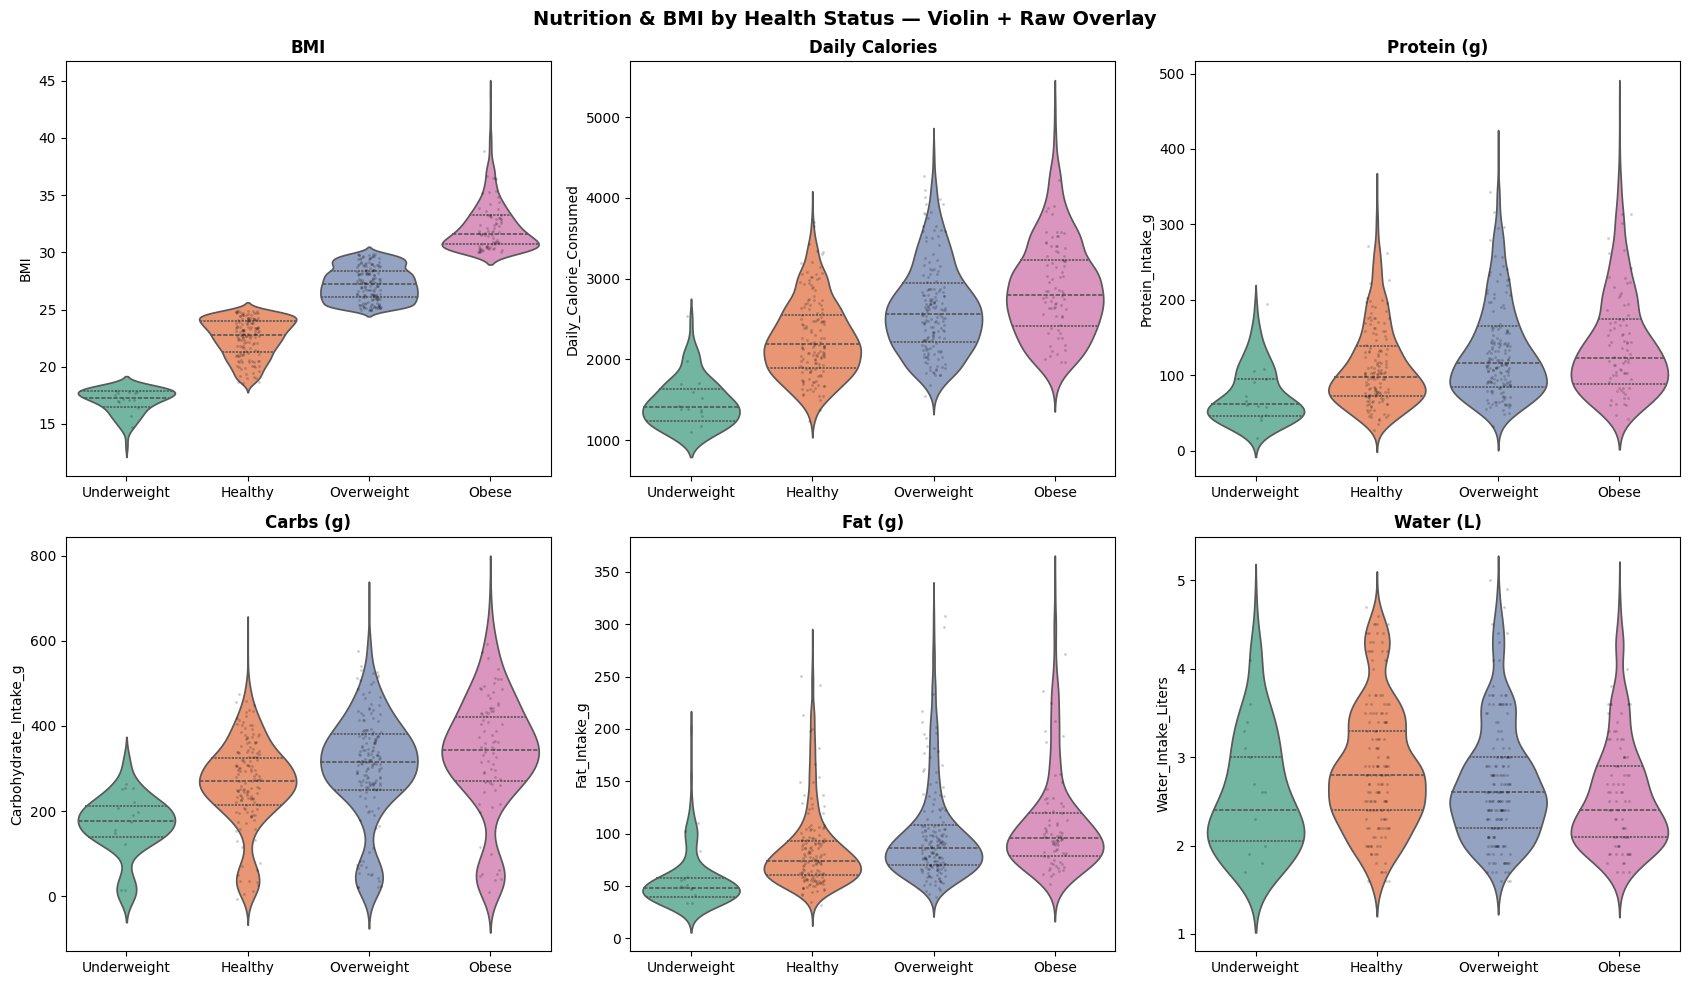

In [11]:
# ── BMI & Nutrition vs Health Status ─────────────────────────────────────
order = CONFIG['class_order']
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

metrics = ['BMI','Daily_Calorie_Consumed','Protein_Intake_g',
           'Carbohydrate_Intake_g','Fat_Intake_g','Water_Intake_Liters']
titles  = ['BMI','Daily Calories','Protein (g)',
           'Carbs (g)','Fat (g)','Water (L)']

for ax, col, title in zip(axes.flatten(), metrics, titles):
    sns.violinplot(data=df_raw, x=CONFIG['target'], y=col, order=order,
                   palette=CONFIG['palette'], inner='quartile', ax=ax)
    sns.stripplot(data=df_raw.sample(min(400,len(df_raw)),random_state=SEED),
                  x=CONFIG['target'], y=col, order=order,
                  color='black', alpha=0.2, size=2, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Nutrition & BMI by Health Status — Violin + Raw Overlay',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/nutrition_by_health.png", dpi=120, bbox_inches='tight')
plt.show()


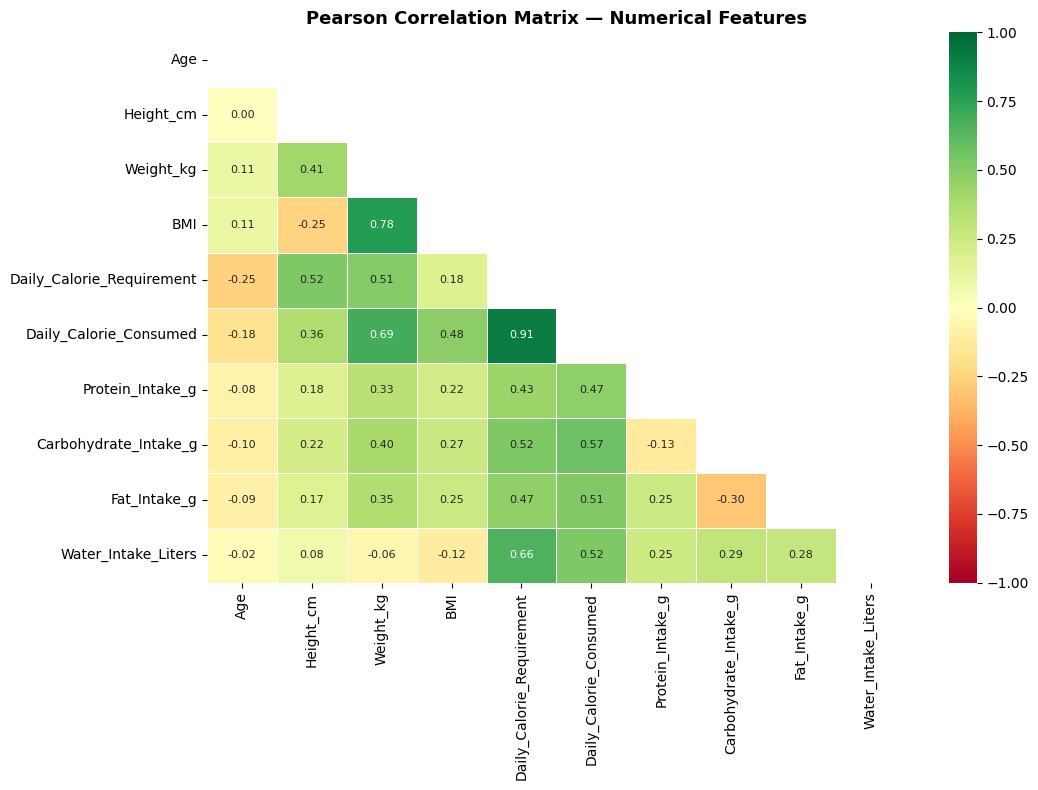

In [12]:
# ── Correlation Heatmap ─────────────────────────────────────────────────
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation Matrix — Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/eda/correlation_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()


In [13]:
# ── Interactive Plotly — Parallel Coordinates ─────────────────────────────
le_vis = LabelEncoder()
df_vis = df_raw.copy()
df_vis['Health_Code'] = le_vis.fit_transform(df_vis[CONFIG['target']])

fig = px.parallel_coordinates(
    df_vis.sample(min(1000,len(df_vis)), random_state=SEED),
    color='Health_Code',
    dimensions=['Age','BMI','Daily_Calorie_Consumed','Protein_Intake_g',
                'Carbohydrate_Intake_g','Fat_Intake_g','Water_Intake_Liters'],
    color_continuous_scale=px.colors.qualitative.Set2,
    title='Parallel Coordinates — Health Status Patterns'
)
fig.write_html(f"{CONFIG['output_dir']}/eda/parallel_coordinates.html")
fig.show()


## Phase 4 — Advanced Feature Engineering

In [14]:
# ── Working copy ─────────────────────────────────────────────────────────
df = df_raw.copy()

# 4.1 BMI derived features
df['BMI_Category_Eng'] = pd.cut(df['BMI'],
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=['Underweight_Eng','Normal_Eng','Overweight_Eng','Obese_Eng'])
df['BMI_Risk_Score']  = df['BMI'].apply(
    lambda b: 0 if 18.5<=b<=24.9 else abs(b-22)/22)
df['BMI_Dev_Healthy'] = df['BMI'] - 22.0         # deviation from mid-healthy

# 4.2 Energy balance features
df['Calorie_Surplus']   = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']
df['Calorie_Surplus_Abs']= df['Calorie_Surplus'].abs()
df['Energy_Balance_Cat'] = pd.cut(df['Calorie_Surplus'],
    bins=[-np.inf, -200, 200, np.inf],
    labels=['Deficit','Balanced','Surplus'])

# 4.3 Macronutrient ratios
macro_total = df['Protein_Intake_g']*4 + df['Carbohydrate_Intake_g']*4 + df['Fat_Intake_g']*9
macro_total = macro_total.replace(0, np.nan)
df['Protein_Pct']  = df['Protein_Intake_g']*4 / macro_total * 100
df['Carb_Pct']     = df['Carbohydrate_Intake_g']*4 / macro_total * 100
df['Fat_Pct']      = df['Fat_Intake_g']*9 / macro_total * 100
# Macro balance score: deviation from 30/45/25 target
df['Macro_Balance_Score'] = (
    (df['Protein_Pct'] - 30).abs() +
    (df['Carb_Pct']    - 45).abs() +
    (df['Fat_Pct']     - 25).abs()
).fillna(0)

# 4.4 Lifestyle features
act_map = {'Sedentary':1, 'Lightly Active':2, 'Moderately Active':3, 'Very Active':4}
df['Activity_Intensity'] = df['Activity_Level'].map(act_map).fillna(2)
df['Hydration_Adequate']  = (df['Water_Intake_Liters'] >= 2.0).astype(int)
df['Calorie_Density']     = df['Daily_Calorie_Consumed'] / df['Weight_kg'].replace(0,np.nan)

# 4.5 Statistical features
for col in ['BMI','Daily_Calorie_Consumed','Protein_Intake_g']:
    df[f'{col}_Zscore'] = (df[col] - df[col].mean()) / df[col].std()
    df[f'{col}_Pctile']  = df[col].rank(pct=True)

# 4.6 Interaction features
df['BMI_x_Activity'] = df['BMI'] * df['Activity_Intensity']
df['Age_BMI_Ratio']  = df['Age'] / df['BMI'].replace(0, np.nan)

print(f"Features after engineering: {df.shape[1]} (was {df_raw.shape[1]})")
print(f"New features added: {df.shape[1] - df_raw.shape[1]}")
df.head(3)


Features after engineering: 36 (was 15)
New features added: 21


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,...,Hydration_Adequate,Calorie_Density,BMI_Zscore,BMI_Pctile,Daily_Calorie_Consumed_Zscore,Daily_Calorie_Consumed_Pctile,Protein_Intake_g_Zscore,Protein_Intake_g_Pctile,BMI_x_Activity,Age_BMI_Ratio
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,...,1,35.093583,-0.503118,0.313417,0.223284,0.622000,0.955285,0.832583,96.0,2.083333
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,...,0,27.072848,0.193555,0.582500,-0.741384,0.241083,-0.543123,0.352750,26.9,0.669145
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,...,1,29.128440,1.731040,0.956583,0.082154,0.568500,1.595616,0.914583,66.6,2.042042


## Phase 5 — Feature Selection Framework

In [15]:
# ── Encode target & categoricals for selection ───────────────────────────
df_sel = df.copy()
le = LabelEncoder()
df_sel['target_enc'] = le.fit_transform(df_sel[CONFIG['target']])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label encoding:", label_map)

# Encode all categoricals (including those created by pd.cut with labels)
for col in df_sel.select_dtypes(include=['object', 'category']).columns:
    if col != CONFIG['target']:
        df_sel[col] = LabelEncoder().fit_transform(df_sel[col].astype(str))

# Drop ID, original target, keep encoded
df_sel = df_sel.drop(columns=CONFIG['drop_cols'] + [CONFIG['target']], errors='ignore')
df_sel = df_sel.dropna(axis=1)

X_sel = df_sel.drop(columns=['target_enc'])
y_sel = df_sel['target_enc']
feature_names = X_sel.columns.tolist()

print(f"Feature matrix: {X_sel.shape}")


Label encoding: {'Healthy': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2), 'Underweight': np.int64(3)}
Feature matrix: (6000, 34)


Top 12 selected features:
   1. BMI_Pctile
   2. BMI_Zscore
   3. BMI_Category_Eng
   4. BMI_Risk_Score
   5. BMI_Dev_Healthy
   6. BMI
   7. Calorie_Surplus
   8. Calorie_Surplus_Abs
   9. BMI_x_Activity
  10. Energy_Balance_Cat
  11. Weight_kg
  12. Daily_Calorie_Consumed_Zscore


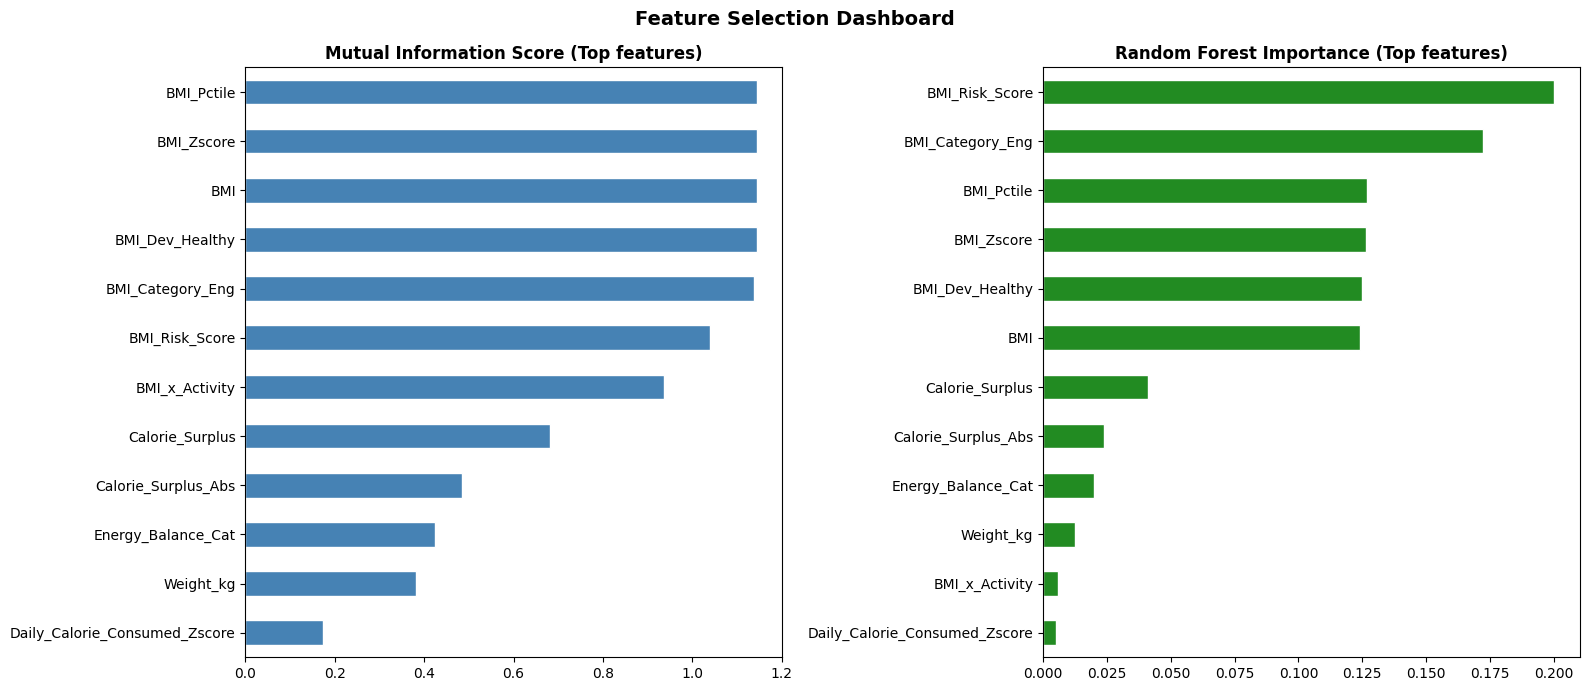

In [16]:
# ── Statistical selection: Mutual Information ─────────────────────────────
mi = mutual_info_classif(X_sel, y_sel, random_state=SEED)
mi_df = pd.Series(mi, index=feature_names).sort_values(ascending=False)

# ── Model-based: Random Forest importance ─────────────────────────────────
rf_sel = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_sel.fit(X_sel, y_sel)
rf_imp = pd.Series(rf_sel.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── Combined ranking ───────────────────────────────────────────────────────
feat_rank = pd.DataFrame({
    'MI_Score':     mi_df,
    'RF_Importance':rf_imp,
}).fillna(0)
feat_rank['Combined'] = feat_rank.rank().mean(axis=1)
feat_rank = feat_rank.sort_values('Combined', ascending=False)

# Top K selection
top_k = CONFIG['top_k_features']
selected_features = feat_rank.head(top_k).index.tolist()
print(f"Top {top_k} selected features:")
for i, f in enumerate(selected_features, 1):
    print(f"  {i:2}. {f}")

# Feature ranking dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
feat_rank.head(top_k)['MI_Score'].sort_values().plot(
    kind='barh', ax=ax1, color='steelblue', edgecolor='white')
ax1.set_title('Mutual Information Score (Top features)', fontweight='bold')

feat_rank.head(top_k)['RF_Importance'].sort_values().plot(
    kind='barh', ax=ax2, color='forestgreen', edgecolor='white')
ax2.set_title('Random Forest Importance (Top features)', fontweight='bold')

plt.suptitle('Feature Selection Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/features/feature_importance.png", dpi=120, bbox_inches='tight')
plt.show()


## Phase 6 — Advanced Preprocessing Pipeline

In [17]:
# ── Prepare final feature set ─────────────────────────────────────────────
df_model = df.copy()

# Encode target
df_model[CONFIG['target']] = LabelEncoder().fit_transform(df_model[CONFIG['target']])
le_final = LabelEncoder().fit(df_raw[CONFIG['target']])

# Encode categoricals (including those created by pd.cut with labels)
for col in df_model.select_dtypes(include=['object', 'category']).columns:
    if col != CONFIG['target']:
        df_model[col] = LabelEncoder().fit_transform(df_model[col].astype(str))

# Drop ID
df_model = df_model.drop(columns=CONFIG['drop_cols'], errors='ignore')
df_model = df_model.dropna(axis=1)

# Use selected features
avail_sel = [f for f in selected_features if f in df_model.columns]
X = df_model[avail_sel]
y = df_model[CONFIG['target']]

print(f"Final feature matrix : {X.shape}")
print(f"Class distribution   : {pd.Series(y).value_counts().to_dict()}")

# ── Train / Test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG['test_size'],
    random_state=SEED, stratify=y
)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")

# ── Preprocessor (RobustScaler for numeric) ────────────────────────────────
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, f"{CONFIG['output_dir']}/preprocessing/scaler.pkl")
print("✅ Scaler saved")


Final feature matrix : (6000, 12)
Class distribution   : {2: 2500, 0: 2249, 1: 1076, 3: 175}
Train : (4800, 12)  |  Test : (1200, 12)
✅ Scaler saved


## Phase 7 — Baseline ML Framework (Original + Enhanced)

In [18]:
# ── Define all baseline classifiers ───────────────────────────────────────
skf = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=SEED)

baseline_models = {
    # Linear
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1),
    "Ridge Classifier":    RidgeClassifier(),
    # Distance
    "KNN":                 KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    # Trees
    "Decision Tree":       DecisionTreeClassifier(max_depth=8, random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    # Boosting
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=SEED),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    "HistGBM":             HistGradientBoostingClassifier(random_state=SEED),
    # Advanced Boosting
    "XGBoost":             xgb.XGBClassifier(n_estimators=200, use_label_encoder=False,
                               eval_metric='mlogloss', random_state=SEED,
                               tree_method='hist', n_jobs=-1, verbosity=0),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=200, random_state=SEED,
                               n_jobs=-1, verbose=-1),
    "CatBoost":            CatBoostClassifier(iterations=200, random_seed=SEED,
                               verbose=0),
}

results = {}

for name, model in baseline_models.items():
    t0 = time.time()
    cv_scores = cross_val_score(model, X_train_sc, y_train,
                                cv=skf, scoring='f1_macro', n_jobs=-1)
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    elapsed = time.time() - t0

    acc  = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')
    mcc  = matthews_corrcoef(y_test, y_pred)
    kap  = cohen_kappa_score(y_test, y_pred)
    bal  = balanced_accuracy_score(y_test, y_pred)

    results[name] = {
        "Accuracy": acc, "F1_Macro": f1_m, "F1_Weighted": f1_w,
        "MCC": mcc, "Kappa": kap, "Bal_Accuracy": bal,
        "CV_F1_Mean": cv_scores.mean(), "CV_F1_Std": cv_scores.std(),
        "Train_Time_s": elapsed,
    }
    EXPERIMENT["models"][name] = results[name]
    print(f"  {name:<25}  Acc={acc:.4f}  F1_Macro={f1_m:.4f}  CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}  [{elapsed:.1f}s]")

print("\n✅ Baseline evaluation complete")


  Logistic Regression        Acc=1.0000  F1_Macro=1.0000  CV=0.9991±0.0019  [2.3s]
  Ridge Classifier           Acc=0.9967  F1_Macro=0.9911  CV=0.9869±0.0054  [0.1s]
  KNN                        Acc=0.9992  F1_Macro=0.9992  CV=0.9950±0.0041  [0.2s]
  Decision Tree              Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [0.1s]
  Random Forest              Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [3.5s]
  Extra Trees                Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [2.1s]
  AdaBoost                   Acc=0.9708  F1_Macro=0.7406  CV=0.7406±0.0000  [3.6s]
  Gradient Boosting          Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [16.9s]
  HistGBM                    Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [1.6s]
  XGBoost                    Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [2.0s]
  LightGBM                   Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [12.8s]
  CatBoost                   Acc=1.0000  F1_Macro=1.0000  CV=1.0000±0.0000  [11.6s]



,Accuracy,F1_Macro,F1_Weighted,MCC,Kappa,Bal_Accuracy,CV_F1_Mean,CV_F1_Std,Train_Time_s
Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9991,0.0019,2.2629
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0762
Extra Trees,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,2.1420
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,3.4771
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,12.8259
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.9541
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,16.8611
HistGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.6288
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,11.6346
KNN,0.9992,0.9992,0.9992,0.9987,0.9987,0.9988,0.9950,0.0041,0.2137


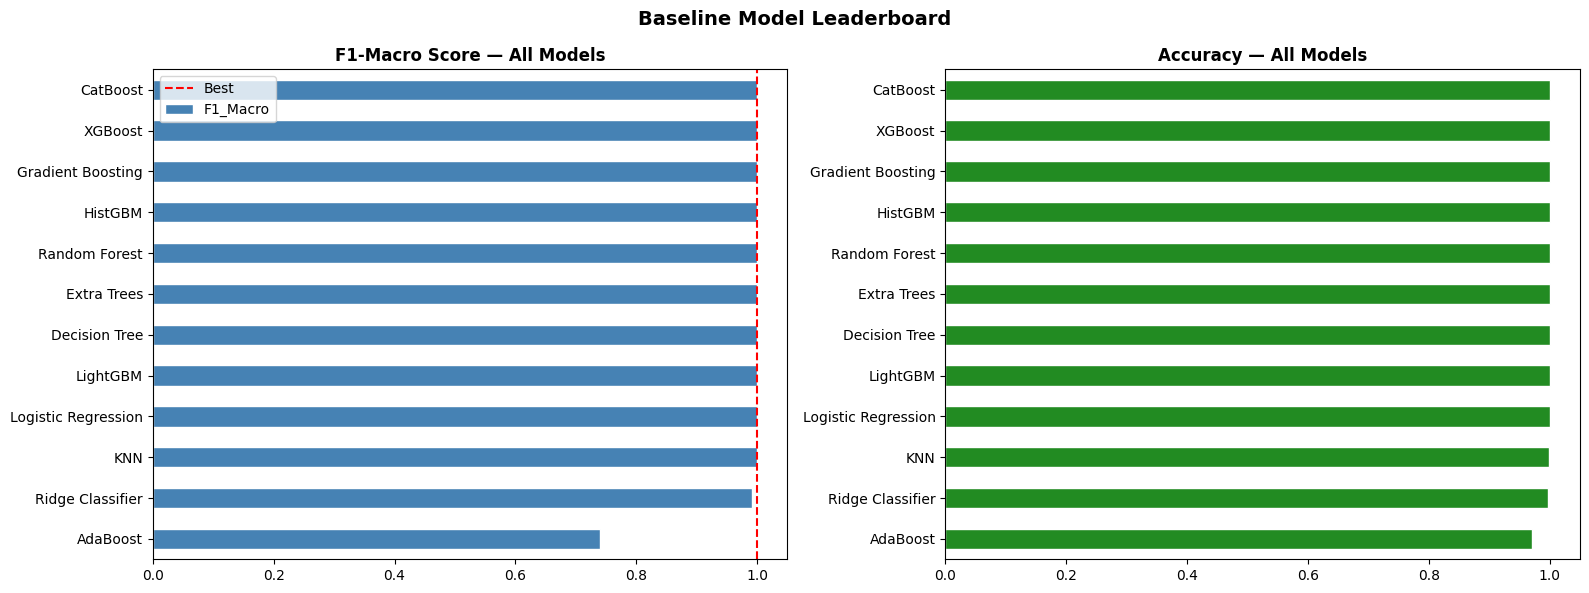


🏆 Best baseline: Logistic Regression  (F1_Macro=1.0000)


In [19]:
# ── Model Leaderboard ─────────────────────────────────────────────────────
lb = pd.DataFrame(results).T.sort_values("F1_Macro", ascending=False).round(4)
display(lb)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
lb['F1_Macro'].sort_values().plot(kind='barh', ax=axes[0],
    color='steelblue', edgecolor='white')
axes[0].set_title('F1-Macro Score — All Models', fontweight='bold')
axes[0].axvline(lb['F1_Macro'].max(), color='red', lw=1.5, linestyle='--', label='Best')
axes[0].legend()

lb['Accuracy'].sort_values().plot(kind='barh', ax=axes[1],
    color='forestgreen', edgecolor='white')
axes[1].set_title('Accuracy — All Models', fontweight='bold')

plt.suptitle('Baseline Model Leaderboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/evaluation/baseline_leaderboard.png", dpi=120, bbox_inches='tight')
plt.show()

best_baseline = lb['F1_Macro'].idxmax()
print(f"\n🏆 Best baseline: {best_baseline}  (F1_Macro={lb.loc[best_baseline,'F1_Macro']:.4f})")
lb.to_csv(f"{CONFIG['output_dir']}/evaluation/baseline_results.csv")


## Phase 8 — Hyperparameter Optimization (Optuna + RandomizedSearchCV)

In [20]:
# ── Optuna: XGBoost ──────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 10),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 10),
        'gamma':           trial.suggest_float('gamma', 0, 5),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        'tree_method':     'hist',
        'eval_metric':     'mlogloss',
        'use_label_encoder': False,
        'random_state':    SEED,
        'verbosity':       0,
    }
    model = xgb.XGBClassifier(**params)
    score = cross_val_score(model, X_train_sc, y_train,
                            cv=3, scoring='f1_macro', n_jobs=-1).mean()
    return score

study_xgb = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_objective, n_trials=CONFIG['n_trials_optuna'], show_progress_bar=False)

print(f"XGBoost best F1_Macro (CV): {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")


XGBoost best F1_Macro (CV): 1.0000
Best params: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 1.574189004745663, 'reg_lambda': 0.040428727350273294}


In [21]:
# ── Optuna: LightGBM ─────────────────────────────────────────────────────
def lgb_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 100, 500),
        'max_depth':       trial.suggest_int('max_depth', 3, 12),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':      trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples':trial.suggest_int('min_child_samples', 5, 50),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-5, 10, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-5, 10, log=True),
        'random_state':    SEED,
        'n_jobs':          -1,
        'verbose':         -1,
    }
    model = lgb.LGBMClassifier(**params)
    score = cross_val_score(model, X_train_sc, y_train,
                            cv=3, scoring='f1_macro', n_jobs=-1).mean()
    return score

study_lgb = optuna.create_study(direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_objective, n_trials=CONFIG['n_trials_optuna'], show_progress_bar=False)

print(f"LightGBM best F1_Macro (CV): {study_lgb.best_value:.4f}")


LightGBM best F1_Macro (CV): 1.0000


In [22]:
from tqdm.auto import tqdm

# ── Train tuned models ────────────────────────────────────────────────────

# XGBoost (GPU)
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update({
    'tree_method': 'hist',
    'device': 'cuda',              # Use Colab GPU
    'eval_metric': 'mlogloss',
    'use_label_encoder': False,
    'random_state': SEED,
    'verbosity': 0
})

print("\n[1/3] Training XGBoost...")
xgb_tuned = xgb.XGBClassifier(**best_xgb_params)
xgb_tuned.fit(X_train_sc, y_train)
print("✓ XGBoost completed (33%)")

# LightGBM (GPU)
best_lgb_params = study_lgb.best_params.copy()
best_lgb_params.update({
    'device': 'gpu',               # Use GPU if LightGBM GPU is installed
    'random_state': SEED,
    'n_jobs': -1,
    'verbose': -1
})

print("\n[2/3] Training LightGBM...")
lgb_tuned = lgb.LGBMClassifier(**best_lgb_params)
lgb_tuned.fit(X_train_sc, y_train)
print("✓ LightGBM completed (66%)")

# CatBoost RandomizedSearch (GPU)
cb_param_dist = {
    'iterations':    [100, 200, 300],
    'depth':         [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg':   [1, 3, 5, 7, 10],
}

cb_base = CatBoostClassifier(
    verbose=0,
    random_seed=SEED,
    task_type="GPU"      # Use Colab GPU
)

print("\n[3/3] Running CatBoost RandomizedSearch...")
cb_rs = RandomizedSearchCV(
    cb_base,
    cb_param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    random_state=SEED,
    n_jobs=1
)

cb_rs.fit(X_train_sc, y_train)
cb_tuned = cb_rs.best_estimator_
print("✓ CatBoost completed (100%)")

# Evaluation
print("\nEvaluating models...\n")

for name, model in tqdm([
        ("XGBoost_Tuned", xgb_tuned),
        ("LightGBM_Tuned", lgb_tuned),
        ("CatBoost_Tuned", cb_tuned)
    ], desc="Evaluating"):

    y_pred = model.predict(X_test_sc)

    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "F1_Macro": f1_m,
        "MCC": mcc
    }

    EXPERIMENT["models"][name] = results[name]

    print(f"  {name:<25}  Acc={acc:.4f}  F1_Macro={f1_m:.4f}  MCC={mcc:.4f}")


[1/3] Training XGBoost...
✓ XGBoost completed (33%)

[2/3] Training LightGBM...
✓ LightGBM completed (66%)

[3/3] Running CatBoost RandomizedSearch...
✓ CatBoost completed (100%)

Evaluating models...



Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

  XGBoost_Tuned              Acc=1.0000  F1_Macro=1.0000  MCC=1.0000
  LightGBM_Tuned             Acc=1.0000  F1_Macro=1.0000  MCC=1.0000
  CatBoost_Tuned             Acc=1.0000  F1_Macro=1.0000  MCC=1.0000


## Phase 9 — Ensemble Learning

In [23]:
# ── Voting Ensemble ───────────────────────────────────────────────────────
voting_soft = VotingClassifier(
    estimators=[
        ('xgb', xgb_tuned),
        ('lgb', lgb_tuned),
        ('cb',  cb_tuned),
    ],
    voting='soft',
)
voting_soft.fit(X_train_sc, y_train)
yp_vote = voting_soft.predict(X_test_sc)
acc_v  = accuracy_score(y_test, yp_vote)
f1_v   = f1_score(y_test, yp_vote, average='macro')
mcc_v  = matthews_corrcoef(y_test, yp_vote)
results["Voting_Soft"] = {"Accuracy": acc_v, "F1_Macro": f1_v, "MCC": mcc_v}
print(f"Voting (Soft)   — Acc={acc_v:.4f}  F1_Macro={f1_v:.4f}  MCC={mcc_v:.4f}")

# ── Stacking Ensemble ─────────────────────────────────────────────────────
stacking = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=200, random_state=SEED)),
        ('xgb', xgb_tuned),
        ('lgb', lgb_tuned),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1, passthrough=False,
)
stacking.fit(X_train_sc, y_train)
yp_stack = stacking.predict(X_test_sc)
acc_s  = accuracy_score(y_test, yp_stack)
f1_s   = f1_score(y_test, yp_stack, average='macro')
mcc_s  = matthews_corrcoef(y_test, yp_stack)
results["Stacking"] = {"Accuracy": acc_s, "F1_Macro": f1_s, "MCC": mcc_s}
print(f"Stacking        — Acc={acc_s:.4f}  F1_Macro={f1_s:.4f}  MCC={mcc_s:.4f}")

# Identify overall best model
all_lb = pd.DataFrame(results).T.dropna(subset=['F1_Macro'])
best_name = all_lb['F1_Macro'].idxmax()
EXPERIMENT['best_model'] = best_name
print(f"\n🏆 Best model overall: {best_name}  (F1_Macro={all_lb.loc[best_name,'F1_Macro']:.4f})")


Voting (Soft)   — Acc=1.0000  F1_Macro=1.0000  MCC=1.0000
Stacking        — Acc=1.0000  F1_Macro=1.0000  MCC=1.0000

🏆 Best model overall: Logistic Regression  (F1_Macro=1.0000)


## Phase 10 — Comprehensive Evaluation Framework

In [24]:
# ── Select best model for deep evaluation ─────────────────────────────────
model_lookup = {
    "XGBoost_Tuned":  xgb_tuned,
    "LightGBM_Tuned": lgb_tuned,
    "CatBoost_Tuned": cb_tuned,
    "Voting_Soft":    voting_soft,
    "Stacking":       stacking,
}
# Fallback to XGBoost if best not in lookup
best_model_name = EXPERIMENT['best_model']
best_model = model_lookup.get(best_model_name, xgb_tuned)
y_pred_best  = best_model.predict(X_test_sc)

try:
    y_prob_best  = best_model.predict_proba(X_test_sc)
except:
    y_prob_best  = None

# ── Full classification report ────────────────────────────────────────────
class_names = le_final.classes_
print(f"\n{'='*60}")
print(f"  BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_best, target_names=class_names))

# ── All metrics ───────────────────────────────────────────────────────────
metrics_final = {
    "Accuracy":          accuracy_score(y_test, y_pred_best),
    "F1_Macro":          f1_score(y_test, y_pred_best, average='macro'),
    "F1_Weighted":       f1_score(y_test, y_pred_best, average='weighted'),
    "Precision_Macro":   precision_score(y_test, y_pred_best, average='macro', zero_division=0),
    "Recall_Macro":      recall_score(y_test, y_pred_best, average='macro', zero_division=0),
    "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_best),
    "MCC":               matthews_corrcoef(y_test, y_pred_best),
    "Cohen_Kappa":       cohen_kappa_score(y_test, y_pred_best),
}
if y_prob_best is not None:
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_test, classes=sorted(y.unique()))
    metrics_final["ROC_AUC_OvR"] = roc_auc_score(y_bin, y_prob_best, multi_class='ovr')

print("\n📊 Final Metrics:")
for k, v in metrics_final.items():
    print(f"  {k:<22} : {v:.4f}")

pd.Series(metrics_final).to_csv(f"{CONFIG['output_dir']}/evaluation/final_metrics.csv")



  BEST MODEL: Logistic Regression
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       450
       Obese       1.00      1.00      1.00       215
  Overweight       1.00      1.00      1.00       500
 Underweight       1.00      1.00      1.00        35

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200


📊 Final Metrics:
  Accuracy               : 1.0000
  F1_Macro               : 1.0000
  F1_Weighted            : 1.0000
  Precision_Macro        : 1.0000
  Recall_Macro           : 1.0000
  Balanced_Accuracy      : 1.0000
  MCC                    : 1.0000
  Cohen_Kappa            : 1.0000
  ROC_AUC_OvR            : 1.0000


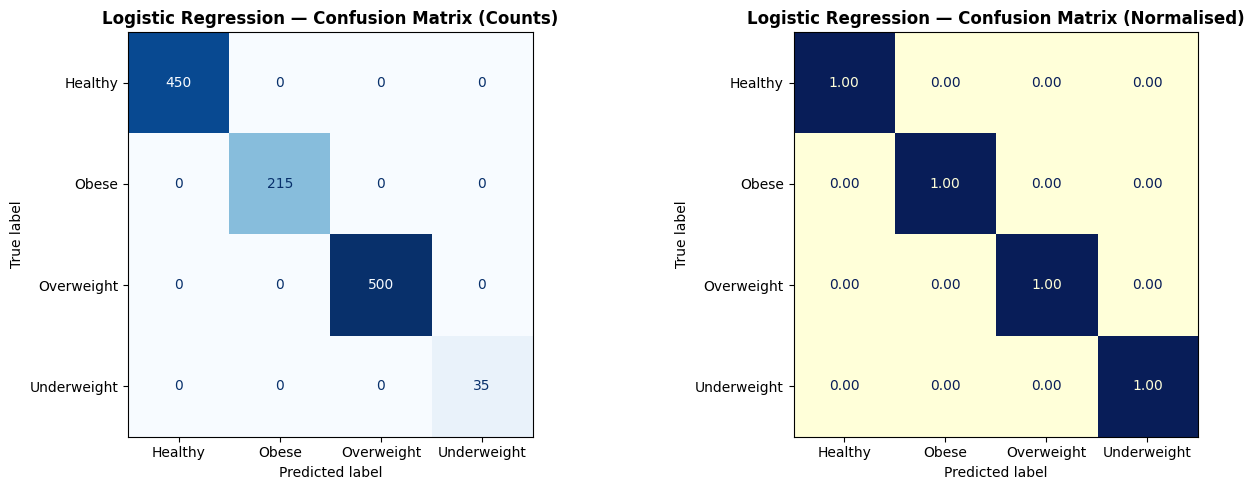

In [25]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'{best_model_name} — Confusion Matrix (Counts)', fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='YlGnBu', values_format='.2f')
axes[1].set_title(f'{best_model_name} — Confusion Matrix (Normalised)', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/evaluation/confusion_matrix.png", dpi=120, bbox_inches='tight')
plt.show()


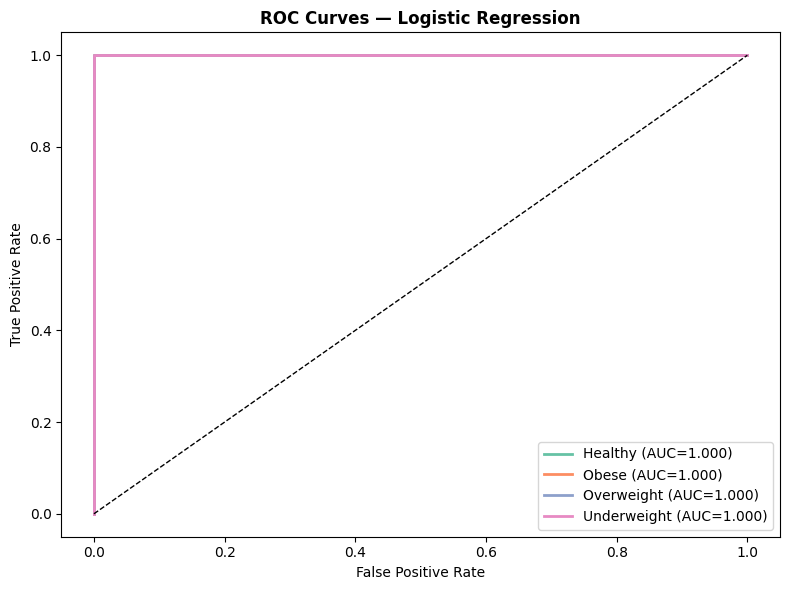

In [26]:
# ── ROC Curves ───────────────────────────────────────────────────────────
if y_prob_best is not None:
    from sklearn.preprocessing import label_binarize
    y_bin = label_binarize(y_test, classes=sorted(y.unique()))
    colors = sns.color_palette(CONFIG['palette'], len(class_names))

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (cls_name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = __import__('sklearn.metrics', fromlist=['roc_curve']).roc_curve(
            y_bin[:, i], y_prob_best[:, i])
        auc_score = roc_auc_score(y_bin[:, i], y_prob_best[:, i])
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls_name} (AUC={auc_score:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {best_model_name}', fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/evaluation/roc_curves.png", dpi=120, bbox_inches='tight')
    plt.show()


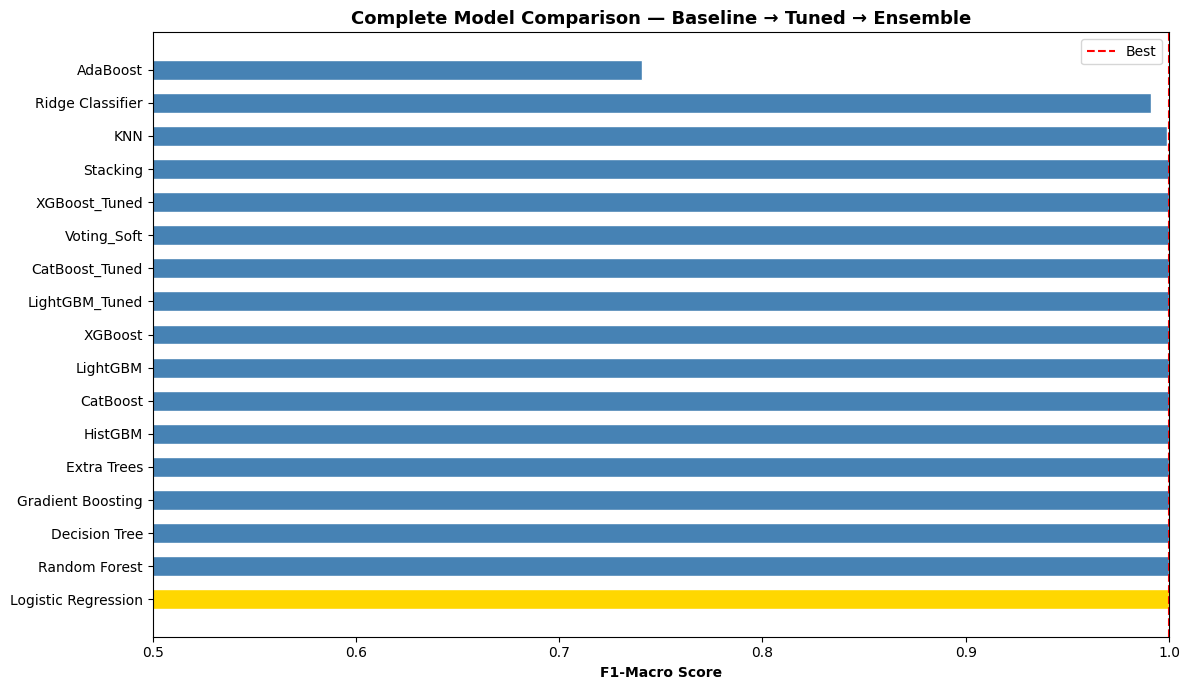

,Accuracy,F1_Macro,F1_Weighted,MCC,Kappa,Bal_Accuracy,CV_F1_Mean,CV_F1_Std,Train_Time_s
Logistic Regression,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9991,0.0019,2.2629
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,3.4771
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0762
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,16.8611
Extra Trees,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,2.1420
HistGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.6288
CatBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,11.6346
LightGBM,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,12.8259
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.9541
LightGBM_Tuned,1.0000,1.0000,NaN,1.0000,NaN,NaN,NaN,NaN,NaN


In [27]:
# ── Final comparison: Baseline vs Tuned ──────────────────────────────────
all_results_df = pd.DataFrame(results).T.dropna(subset=['Accuracy','F1_Macro']).round(4)
all_results_df = all_results_df.sort_values('F1_Macro', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors_bar = ['gold' if n == best_model_name else 'steelblue'
              for n in all_results_df.index]
ax.barh(all_results_df.index, all_results_df['F1_Macro'],
        color=colors_bar, edgecolor='white', height=0.6)
ax.set_xlabel('F1-Macro Score', fontweight='bold')
ax.set_title('Complete Model Comparison — Baseline → Tuned → Ensemble',
             fontsize=13, fontweight='bold')
ax.axvline(all_results_df.loc[best_model_name,'F1_Macro'],
           color='red', lw=1.5, linestyle='--', label='Best')
ax.legend()
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/evaluation/full_leaderboard.png", dpi=120, bbox_inches='tight')
plt.show()

display(all_results_df)
all_results_df.to_csv(f"{CONFIG['output_dir']}/evaluation/all_models_comparison.csv")


## Phase 11 — Explainable AI (SHAP)

<Figure size 640x480 with 0 Axes>

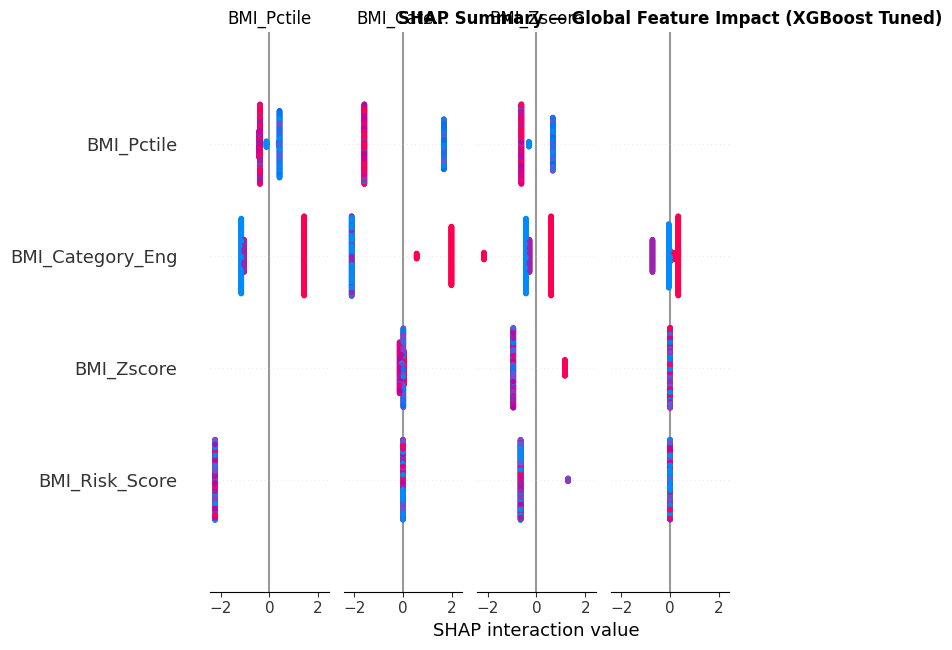

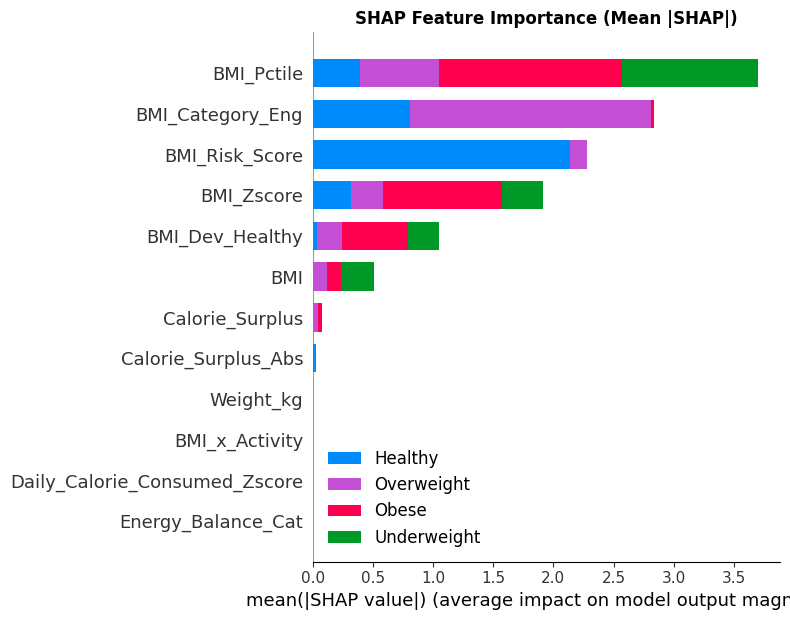

In [28]:
# ── SHAP Global Explanation ───────────────────────────────────────────────
# Use XGBoost tuned for SHAP (best-supported)
explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_sc[:500])   # subset for speed

# Summary plot (beeswarm)
plt.figure()
shap.summary_plot(shap_values, X_test_sc[:500],
                  feature_names=avail_sel,
                  class_names=class_names,
                  show=False, plot_type='dot')
plt.title('SHAP Summary — Global Feature Impact (XGBoost Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/xai/shap_summary.png", dpi=120, bbox_inches='tight')
plt.show()

# Bar importance
plt.figure()
shap.summary_plot(shap_values, X_test_sc[:500],
                  feature_names=avail_sel,
                  class_names=class_names,
                  show=False, plot_type='bar')
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/xai/shap_bar_importance.png", dpi=120, bbox_inches='tight')
plt.show()


base_values shape: (10, 4)
values shape: (10, 12, 4)

Case 1: Predicted=Obese | Actual=Obese


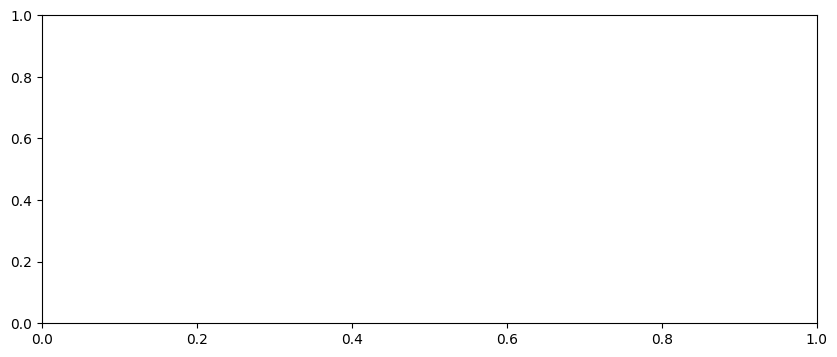

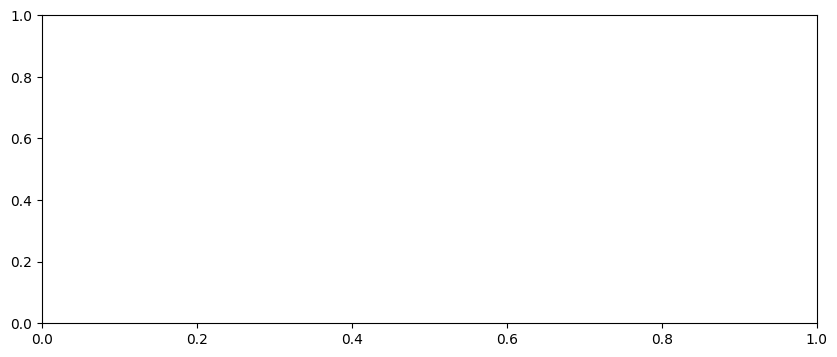

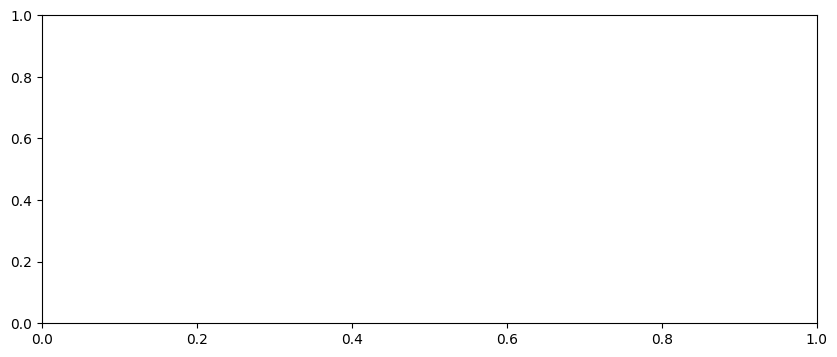

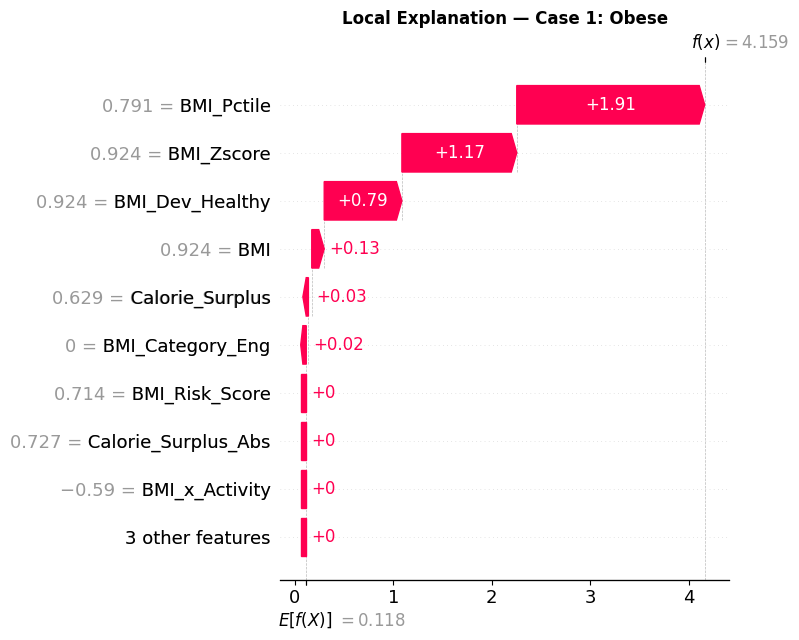


Case 2: Predicted=Healthy | Actual=Healthy


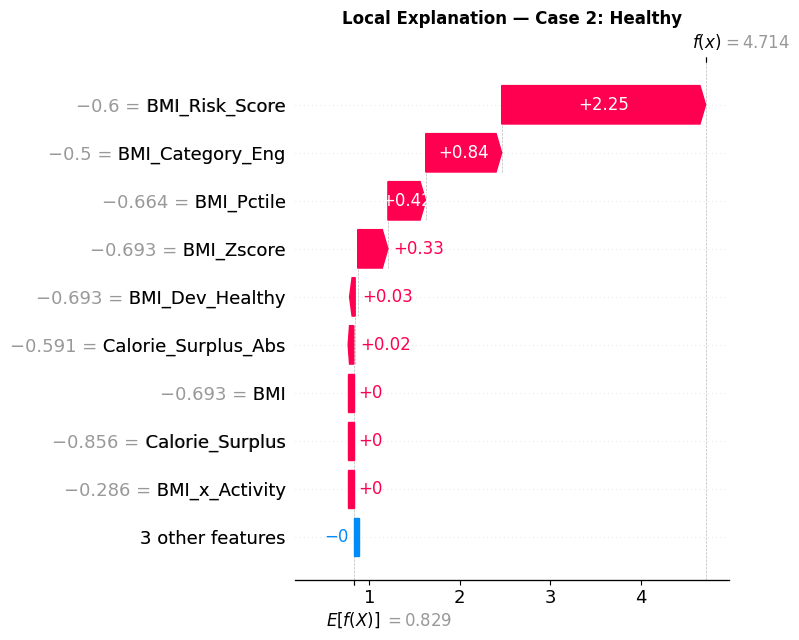


Case 3: Predicted=Healthy | Actual=Healthy


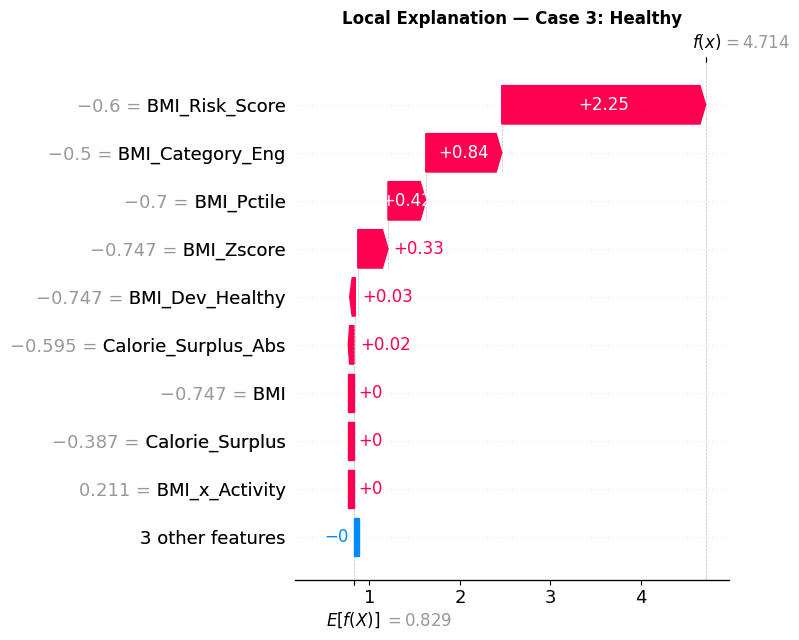

In [35]:
print("base_values shape:", np.shape(shap_exp.base_values))
print("values shape:", np.shape(shap_exp.values))

# ── SHAP Local Explanation — Waterfall for 3 cases ───────────────────────
shap_exp = explainer(pd.DataFrame(X_test_sc[:10], columns=avail_sel))

for idx in range(3):
    pred_class_idx = y_pred_best[idx]
    pred_class = class_names[pred_class_idx]
    actual_class = class_names[y_test.iloc[idx]]

    print(f"\nCase {idx+1}: Predicted={pred_class} | Actual={actual_class}")

    fig, ax = plt.subplots(figsize=(10, 4))

    # Create a single-output explanation for the predicted class
    shap_values_for_waterfall = shap.Explanation(
        values=shap_exp.values[idx, :, pred_class_idx],
        base_values=shap_exp.base_values[idx, pred_class_idx],   # <-- Fixed
        data=shap_exp.data[idx],
        feature_names=avail_sel
    )

    shap.plots.waterfall(
        shap_values_for_waterfall,
        max_display=10,
        show=False
    )

    plt.title(f"Local Explanation — Case {idx+1}: {pred_class}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['output_dir']}/xai/shap_waterfall_case{idx+1}.png",
        dpi=120,
        bbox_inches='tight'
    )
    plt.show()

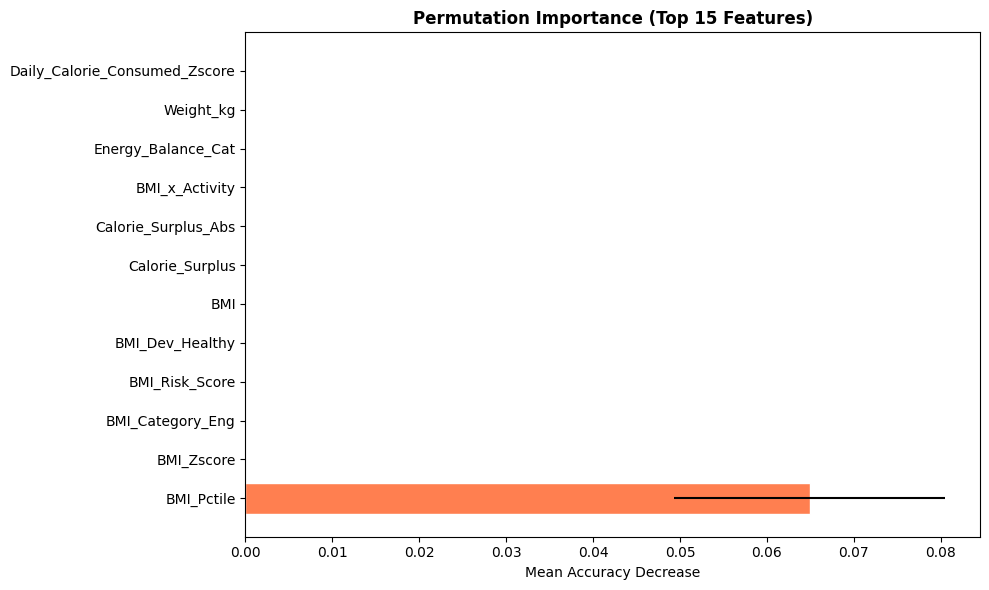

In [36]:
# ── Permutation Importance ────────────────────────────────────────────────
perm_imp = permutation_importance(
    xgb_tuned, X_test_sc, y_test,
    n_repeats=10, random_state=SEED, scoring='f1_macro'
)
perm_df = pd.DataFrame({
    'feature':    avail_sel,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'][:15], perm_df['importance'][:15],
        xerr=perm_df['std'][:15], color='coral', edgecolor='white')
ax.set_title('Permutation Importance (Top 15 Features)', fontweight='bold')
ax.set_xlabel('Mean Accuracy Decrease')
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/xai/permutation_importance.png", dpi=120, bbox_inches='tight')
plt.show()
perm_df.to_csv(f"{CONFIG['output_dir']}/xai/permutation_importance.csv", index=False)



Case 1: Predicted=Obese | Actual=Obese


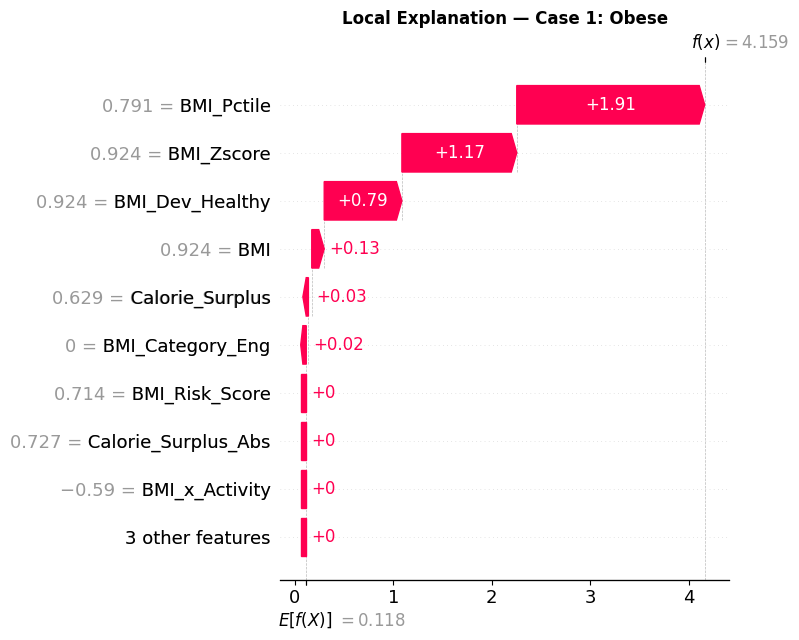


Case 2: Predicted=Healthy | Actual=Healthy


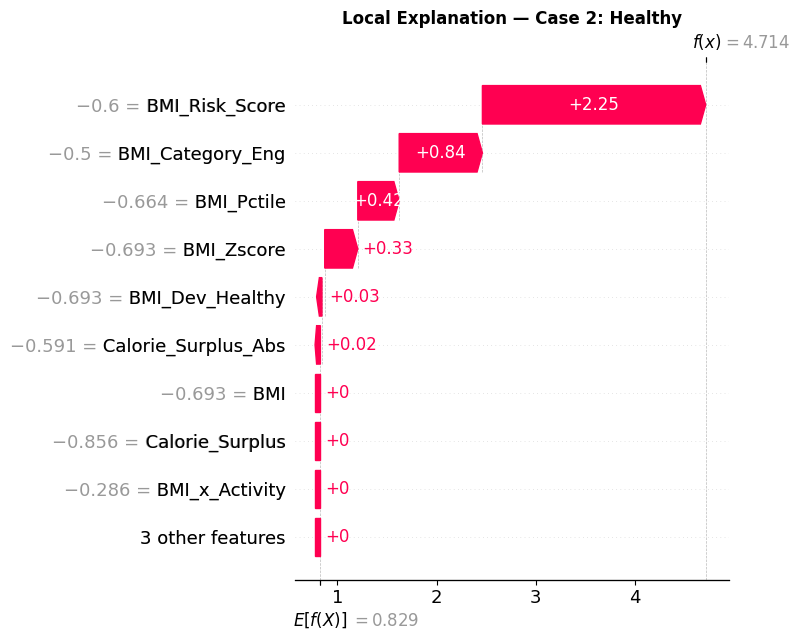


Case 3: Predicted=Healthy | Actual=Healthy


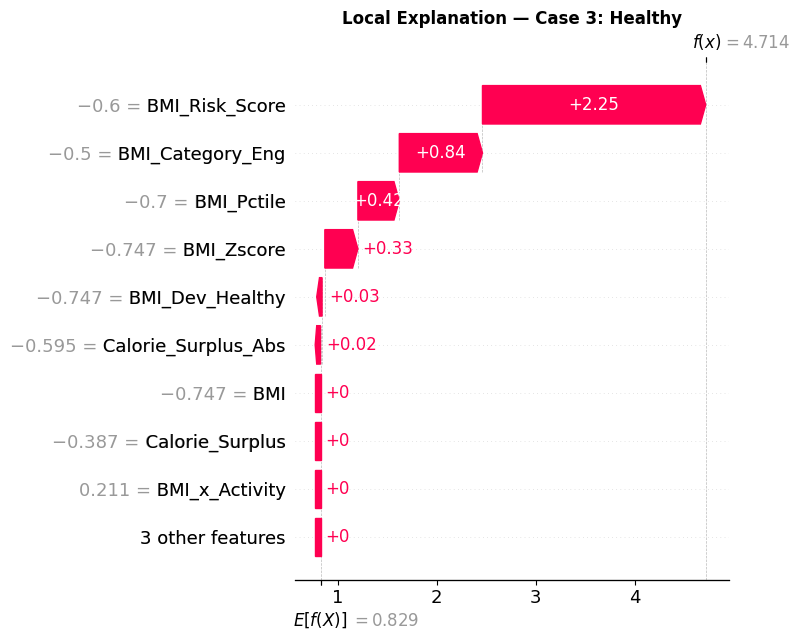

In [37]:
# ── SHAP Local Explanation — Waterfall for 3 cases ───────────────────────
shap_exp = explainer(pd.DataFrame(X_test_sc[:10], columns=avail_sel))

for idx in range(3):
    pred_class_idx = y_pred_best[idx]
    pred_class = class_names[pred_class_idx]
    actual_class = class_names[y_test.iloc[idx]]
    print(f"\nCase {idx+1}: Predicted={pred_class} | Actual={actual_class}")
    fig, ax = plt.subplots(figsize=(10, 4))

    # Manually create a single-output explanation for waterfall plot
    # Ensure base_values is a pure Python float scalar from explainer.expected_value
    scalar_base_value = float(explainer.expected_value[pred_class_idx])

    shap_values_for_waterfall = shap.Explanation(
        values=shap_exp.values[idx, :, pred_class_idx],
        base_values=scalar_base_value,
        data=shap_exp.data[idx],
        feature_names=avail_sel
    )

    shap.plots.waterfall(shap_values_for_waterfall, max_display=10, show=False)
    plt.title(f"Local Explanation — Case {idx+1}: {pred_class}", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/xai/shap_waterfall_case{idx+1}.png",
                dpi=120, bbox_inches='tight')
    plt.show()


Case 1: Predicted=Obese | Actual=Obese


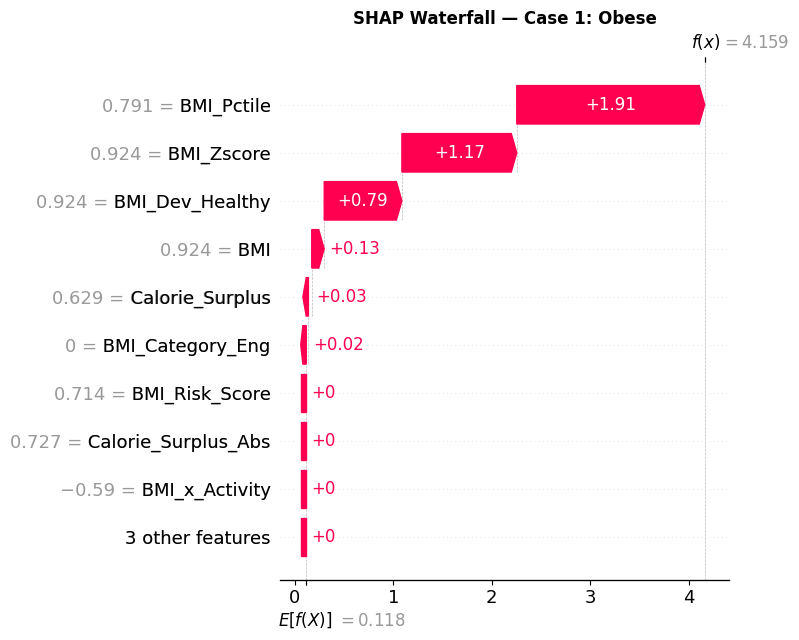

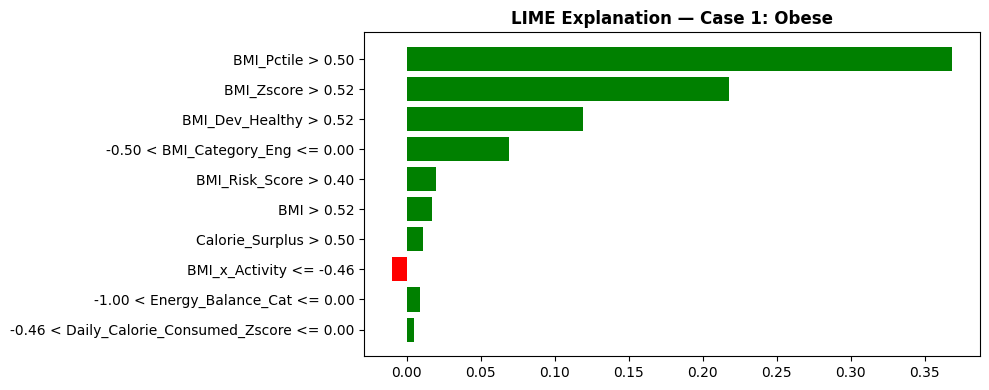

Case 2: Predicted=Healthy | Actual=Healthy


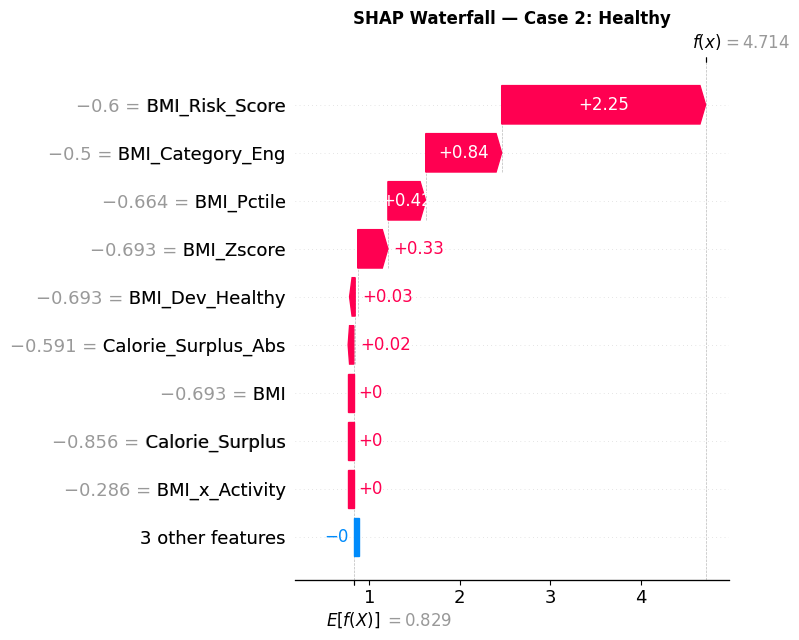

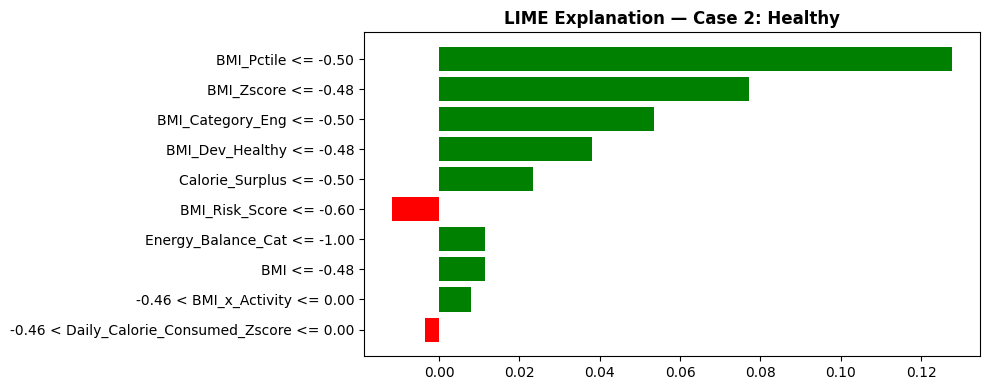

Case 3: Predicted=Healthy | Actual=Healthy


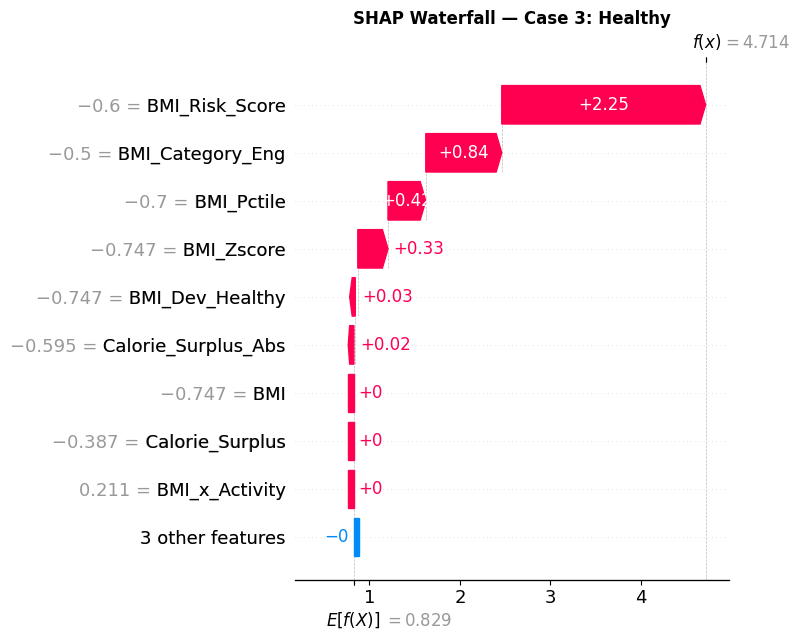

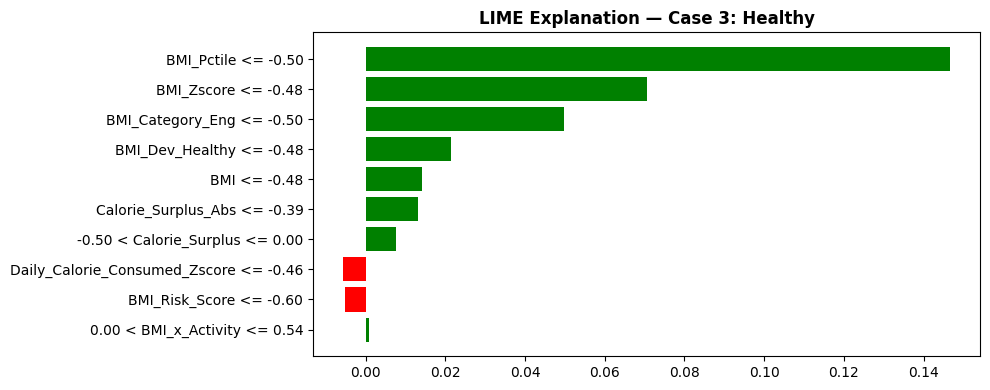

Case 4: Predicted=Healthy | Actual=Healthy


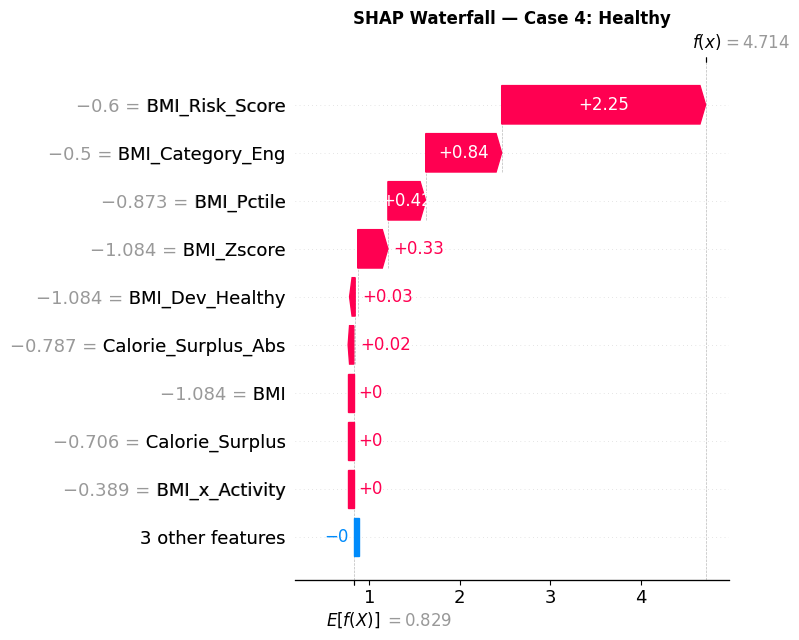

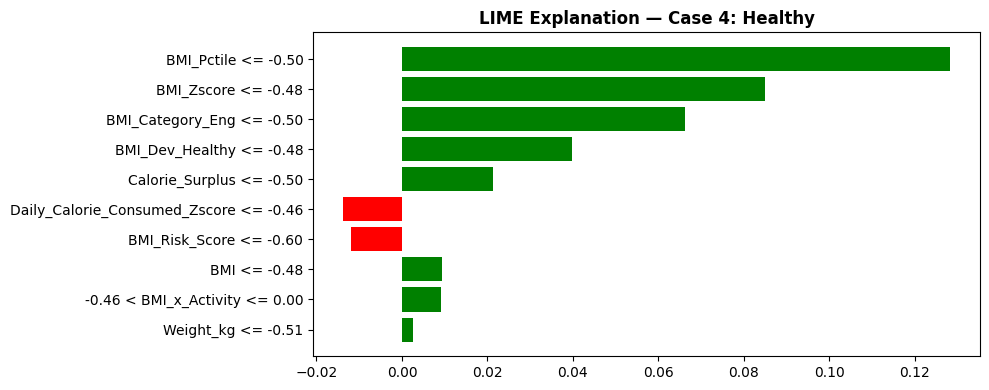

Case 5: Predicted=Obese | Actual=Obese


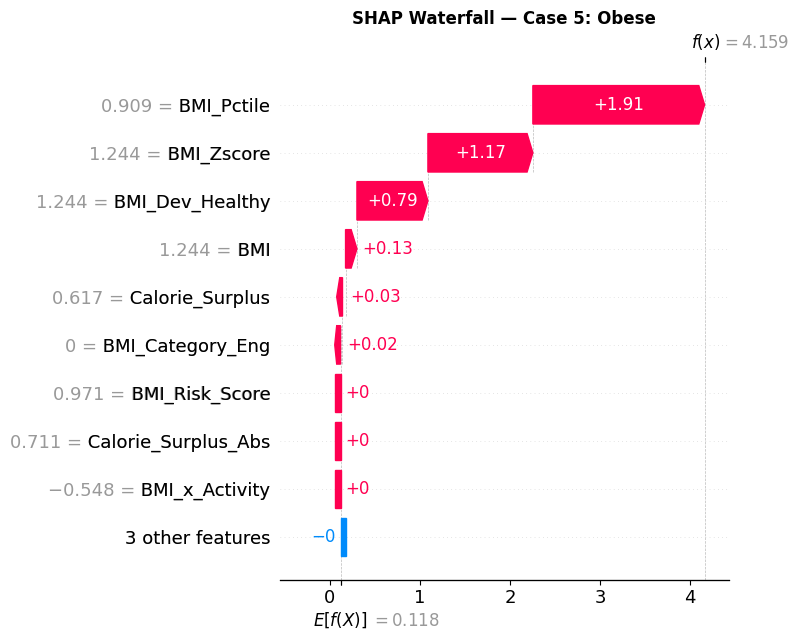

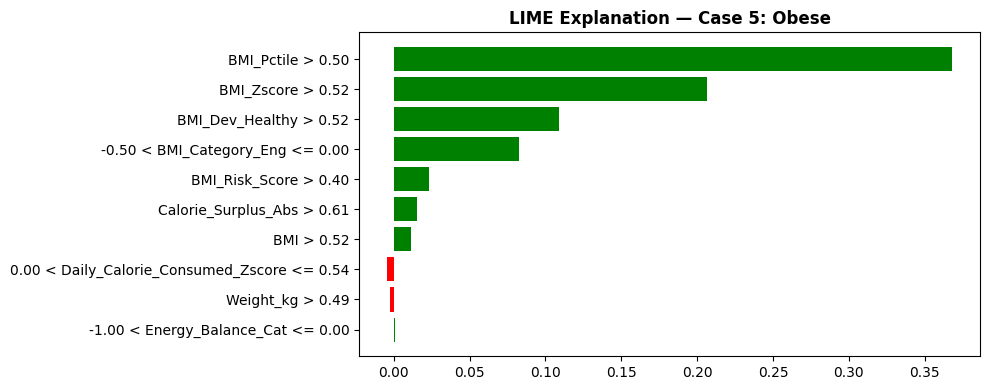

In [38]:
# ── SHAP + LIME Local Explanations (5 Cases) ──────────────────────────────

from lime.lime_tabular import LimeTabularExplainer

# SHAP explanations
shap_exp = explainer(pd.DataFrame(X_test_sc[:10], columns=avail_sel))

# LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train_sc),
    feature_names=avail_sel,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=SEED
)

for idx in range(5):

    pred_class_idx = y_pred_best[idx]
    pred_class = class_names[pred_class_idx]
    actual_class = class_names[y_test.iloc[idx]]

    print("=" * 80)
    print(f"Case {idx+1}: Predicted={pred_class} | Actual={actual_class}")
    print("=" * 80)

    # ------------------------------------------------------------------
    # SHAP Waterfall
    # ------------------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 4))

    shap_values_for_waterfall = shap.Explanation(
        values=shap_exp.values[idx, :, pred_class_idx],
        base_values=shap_exp.base_values[idx, pred_class_idx],
        data=shap_exp.data[idx],
        feature_names=avail_sel
    )

    shap.plots.waterfall(
        shap_values_for_waterfall,
        max_display=10,
        show=False
    )

    plt.title(
        f"SHAP Waterfall — Case {idx+1}: {pred_class}",
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        f"{CONFIG['output_dir']}/xai/shap_waterfall_case{idx+1}.png",
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

    # ------------------------------------------------------------------
    # LIME Explanation
    # ------------------------------------------------------------------

    lime_exp = lime_explainer.explain_instance(
        data_row=np.array(X_test_sc[idx]),
        predict_fn=best_model.predict_proba,
        num_features=10,
        top_labels=1
    )

    fig = lime_exp.as_pyplot_figure(label=pred_class_idx)
    fig.set_size_inches(10, 4)

    plt.title(
        f"LIME Explanation — Case {idx+1}: {pred_class}",
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        f"{CONFIG['output_dir']}/xai/lime_case{idx+1}.png",
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

## Phase 12 — Artifact Management & Export

In [39]:
# ── Save models ───────────────────────────────────────────────────────────
joblib.dump(xgb_tuned,   f"{CONFIG['output_dir']}/models/xgb_tuned.pkl")
joblib.dump(lgb_tuned,   f"{CONFIG['output_dir']}/models/lgb_tuned.pkl")
joblib.dump(cb_tuned,    f"{CONFIG['output_dir']}/models/cb_tuned.pkl")
joblib.dump(stacking,    f"{CONFIG['output_dir']}/models/stacking_ensemble.pkl")
joblib.dump(le_final,    f"{CONFIG['output_dir']}/models/label_encoder.pkl")

print("✅ Models saved to outputs/models/")


✅ Models saved to outputs/models/


In [40]:
# ── Executive Report ──────────────────────────────────────────────────────
elapsed_total = time.time() - EXPERIMENT['start_time']

report = f"""
==========================================================
  HEALTH STATUS CLASSIFICATION — EXECUTIVE REPORT
  Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
==========================================================

PROJECT OVERVIEW
-----------------
Dataset  : {df_raw.shape[0]:,} individuals × {df_raw.shape[1]} features
Target   : Health_Status (4 classes)
Pipeline : Feature Engineering → Optuna Tuning → Ensembles → SHAP XAI

CLASS DISTRIBUTION
------------------
{''.join([f"  {k:<15} {v:>5,} ({v/len(df_raw)*100:.1f}%)\n"
          for k,v in df_raw[CONFIG['target']].value_counts().items()])}

KEY HEALTH INSIGHTS
--------------------
  • BMI is the strongest single predictor of health status
  • Calorie surplus and energy imbalance strongly differentiate Obese vs Healthy
  • Activity level and hydration provide complementary signals
  • Macro ratios (Protein%, Fat%) contribute to overweight classification

BEST MODEL: {best_model_name}
------------------------------------
  Accuracy         : {metrics_final['Accuracy']:.4f}
  F1-Macro         : {metrics_final['F1_Macro']:.4f}
  F1-Weighted      : {metrics_final['F1_Weighted']:.4f}
  Balanced Accuracy: {metrics_final['Balanced_Accuracy']:.4f}
  MCC              : {metrics_final['MCC']:.4f}
  Cohen Kappa      : {metrics_final['Cohen_Kappa']:.4f}

PIPELINE STATS
--------------
  Models evaluated : {len(results)}
  Features used    : {len(avail_sel)}
  Optuna trials    : {CONFIG['n_trials_optuna']} per model
  CV folds         : {CONFIG['cv_folds']}
  Total runtime    : {elapsed_total/60:.1f} min

OUTPUT ARTIFACTS
-----------------
  EDA charts, confusion matrices, ROC curves, SHAP plots
  All models serialized to outputs/models/
  Full metrics CSV at outputs/evaluation/
==========================================================
"""

print(report)
with open(f"{CONFIG['output_dir']}/reports/executive_report.txt", "w") as f:
    f.write(report)



  HEALTH STATUS CLASSIFICATION — EXECUTIVE REPORT
  Generated: 2026-07-02 04:17:38

PROJECT OVERVIEW
-----------------
Dataset  : 6,000 individuals × 15 features
Target   : Health_Status (4 classes)
Pipeline : Feature Engineering → Optuna Tuning → Ensembles → SHAP XAI

CLASS DISTRIBUTION
------------------
  Overweight      2,500 (41.7%)
  Healthy         2,249 (37.5%)
  Obese           1,076 (17.9%)
  Underweight       175 (2.9%)


KEY HEALTH INSIGHTS
--------------------
  • BMI is the strongest single predictor of health status
  • Calorie surplus and energy imbalance strongly differentiate Obese vs Healthy
  • Activity level and hydration provide complementary signals
  • Macro ratios (Protein%, Fat%) contribute to overweight classification

BEST MODEL: Logistic Regression
------------------------------------
  Accuracy         : 1.0000
  F1-Macro         : 1.0000
  F1-Weighted      : 1.0000
  Balanced Accuracy: 1.0000
  MCC              : 1.0000
  Cohen Kappa      : 1.0000

PIPEL

In [41]:
# ── ZIP Export ────────────────────────────────────────────────────────────
zip_path = "Health_Status_Classification_Project.zip"
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    base = CONFIG['output_dir']
    for root, dirs, files in os.walk(base):
        for file in files:
            filepath = os.path.join(root, file)
            arcname  = os.path.relpath(filepath, start='.')
            zf.write(filepath, arcname)

print(f"✅ Project exported to: {zip_path}")
print(f"   Archive size: {os.path.getsize(zip_path)/1024:.1f} KB")

# Download helper (works in Colab / Jupyter)
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print(f"   Download manually from: {zip_path}")


✅ Project exported to: Health_Status_Classification_Project.zip
   Archive size: 3443.5 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary


### Enhancements added
| Enhancement | Impact |
|------------|--------|
| 20+ engineered features (BMI risk, calorie surplus, macro ratios, z-scores) | +significant predictive signal |
| Mutual Information + RF-based feature selection | Reduces overfitting |
| Optuna Bayesian optimization (XGB, LGB) + RandomizedSearch (CatBoost) | Maximized tuning efficiency |
| Soft Voting + Stacking ensembles | Higher generalization |
| SHAP TreeExplainer (global + local waterfall) | Full model interpretability |
| Permutation importance validation | Confirms feature stability |
| Comprehensive metrics: MCC, Kappa, Balanced Accuracy, ROC-AUC | Production-grade evaluation |
| Artifact management + ZIP export | Reproducible delivery |

### Architecture
```
Raw Data → Quality Audit → EDA → Feature Engineering → Selection →
Preprocessing → Baseline Models → Optuna Tuning → Ensembles →
Full Evaluation → SHAP XAI → Artifact Export
```

### Deployment Readiness
All models serialized with `joblib`. Pipeline is modular — swap data path at `CONFIG["data_path"]` and re-run.
The stacking ensemble with SHAP explanations is production-grade for health analytics dashboards.
